<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Fashion_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('fashion_boutique_dataset.csv')
df.head(11)

,product_id,category,brand,season,size,color,original_price,markdown_percentage,current_price,purchase_date,stock_quantity,customer_rating,is_returned,return_reason
0,FB000001,Outerwear,Zara,Spring,XL,Red,196.01,0.0,196.01,2025-07-05,37,3.0,False,NaN
1,FB000002,Tops,Uniqlo,Winter,L,Pink,119.64,0.0,119.64,2025-08-06,2,2.5,False,NaN
2,FB000003,Accessories,Uniqlo,Winter,NaN,Black,33.80,0.0,33.80,2025-08-06,22,4.3,False,NaN
3,FB000004,Shoes,Uniqlo,Spring,XL,Black,75.36,0.0,75.36,2025-07-07,48,2.6,False,NaN
4,FB000005,Tops,Banana Republic,Winter,XL,Black,105.02,0.0,105.02,2025-08-06,10,NaN,False,NaN
5,FB000006,Accessories,Zara,Fall,NaN,White,35.03,35.4,22.63,2025-08-06,38,2.9,True,Color Mismatch
6,FB000007,Bottoms,Zara,Spring,S,Gray,53.83,54.5,24.49,2024-10-29,38,2.6,False,NaN
7,FB000008,Dresses,Mango,Winter,XL,Blue,91.55,22.1,71.32,2025-08-06,47,1.6,False,NaN
8,FB000009,Outerwear,Uniqlo,Spring,XL,Green,227.73,12.8,198.58,2025-03-24,14,NaN,False,NaN
9,FB000010,Outerwear,H&M,Fall,XXL,Pink,248.41,10.9,221.33,2025-08-06,37,NaN,False,NaN


In [4]:
df.tail(11)

,product_id,category,brand,season,size,color,original_price,markdown_percentage,current_price,purchase_date,stock_quantity,customer_rating,is_returned,return_reason
2165,FB002166,Accessories,Banana Republic,Summer,NaN,Black,76.08,0.0,76.08,2025-08-06,6,4.9,False,NaN
2166,FB002167,Shoes,Banana Republic,Winter,M,Brown,116.15,16.5,96.99,2025-08-06,11,3.0,False,NaN
2167,FB002168,Shoes,H&M,Winter,XS,White,98.22,0.0,98.22,2025-08-06,27,3.3,False,NaN
2168,FB002169,Shoes,Ann Taylor,Winter,NaN,Beige,66.58,0.0,66.58,2025-08-06,45,3.4,False,NaN
2169,FB002170,Accessories,Uniqlo,Spring,NaN,Beige,69.22,0.0,69.22,2024-09-05,42,3.8,False,NaN
2170,FB002171,Tops,Uniqlo,Winter,XL,Black,85.01,0.0,85.01,2025-08-06,39,4.3,False,NaN
2171,FB002172,Tops,Mango,Summer,XL,Black,31.41,0.0,31.41,2025-08-06,10,2.1,False,NaN
2172,FB002173,Dresses,Banana Republic,Winter,L,Brown,50.58,0.0,50.58,2025-08-06,1,3.1,True,Changed Mind
2173,FB002174,Accessories,Banana Republic,Winter,NaN,Beige,79.37,54.8,35.88,2025-08-06,40,2.6,False,NaN
2174,FB002175,Bottoms,Ann Taylor,Summer,XL,Pink,105.52,0.0,105.52,2025-08-06,20,4.9,True,Size Issue


In [6]:
df.shape

(2176, 14)

In [8]:
df.columns

Index(['product_id', 'category', 'brand', 'season', 'size', 'color',
       'original_price', 'markdown_percentage', 'current_price',
       'purchase_date', 'stock_quantity', 'customer_rating', 'is_returned',
       'return_reason'],
      dtype='object')

In [10]:
df.dtypes

,0
product_id,object
category,object
brand,object
season,object
size,object
color,object
original_price,float64
markdown_percentage,float64
current_price,float64
purchase_date,object


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2176 entries, 0 to 2175
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           2176 non-null   object 
 1   category             2176 non-null   object 
 2   brand                2176 non-null   object 
 3   season               2176 non-null   object 
 4   size                 1685 non-null   object 
 5   color                2176 non-null   object 
 6   original_price       2176 non-null   float64
 7   markdown_percentage  2176 non-null   float64
 8   current_price        2176 non-null   float64
 9   purchase_date        2176 non-null   object 
 10  stock_quantity       2176 non-null   int64  
 11  customer_rating      1814 non-null   float64
 12  is_returned          2176 non-null   bool   
 13  return_reason        320 non-null    object 
dtypes: bool(1), float64(4), int64(1), object(8)
memory usage: 223.3+ KB


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.isnull().sum()

,0
product_id,0
category,0
brand,0
season,0
size,491
color,0
original_price,0
markdown_percentage,0
current_price,0
purchase_date,0


In [14]:
Q1 = df['original_price'].quantile(0.25)
Q3 = df['original_price'].quantile(0.75)

IQR  = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_outliers = df[(df['original_price'] >= lower_bound) & (df['original_price'] <= upper_bound)].copy()

print('Before removing Outliers:', len(df))
print('After Removing Outliers:', len(df_outliers))

Before removing Outliers: 2176
After Removing Outliers: 2150


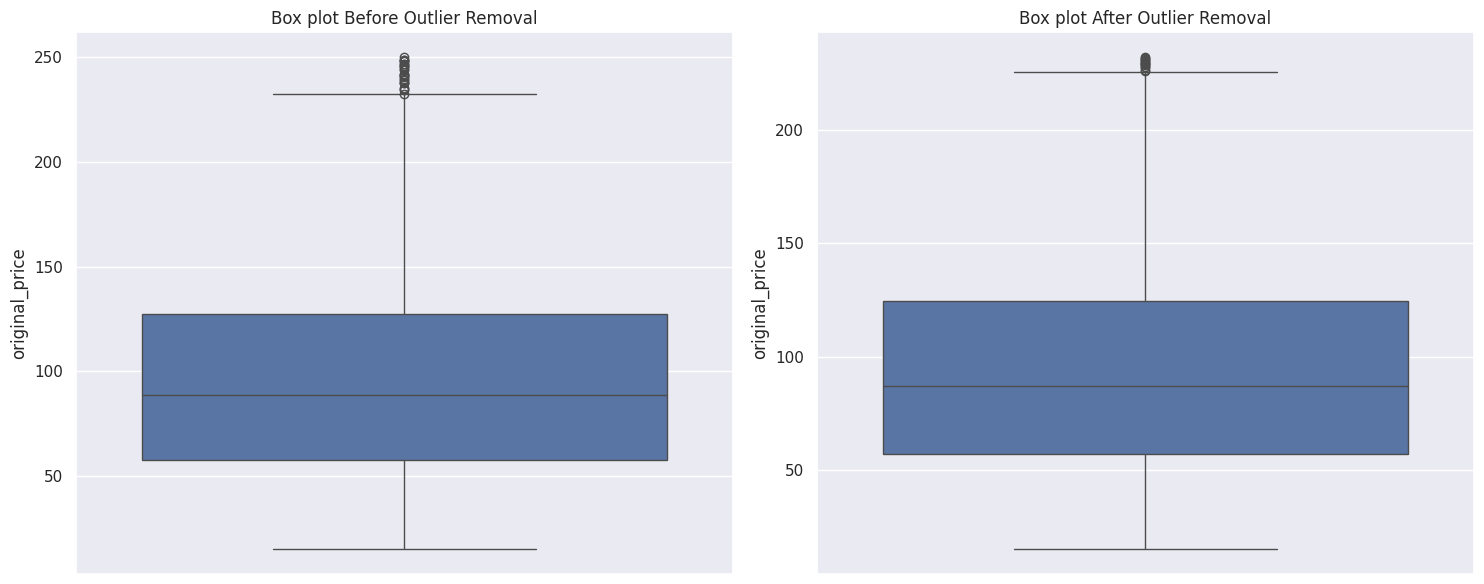

In [16]:
# Creating a figure with two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df, y='original_price', ax=axes[0])
axes[0].set_title('Box plot Before Outlier Removal')
axes[0].set_ylabel('original_price')

sns.boxplot(data=df_outliers, y='original_price', ax=axes[1])
axes[1].set_title('Box plot After Outlier Removal')
axes[1].set_ylabel('original_price')

plt.tight_layout()
plt.show()

# Univariate Analysis

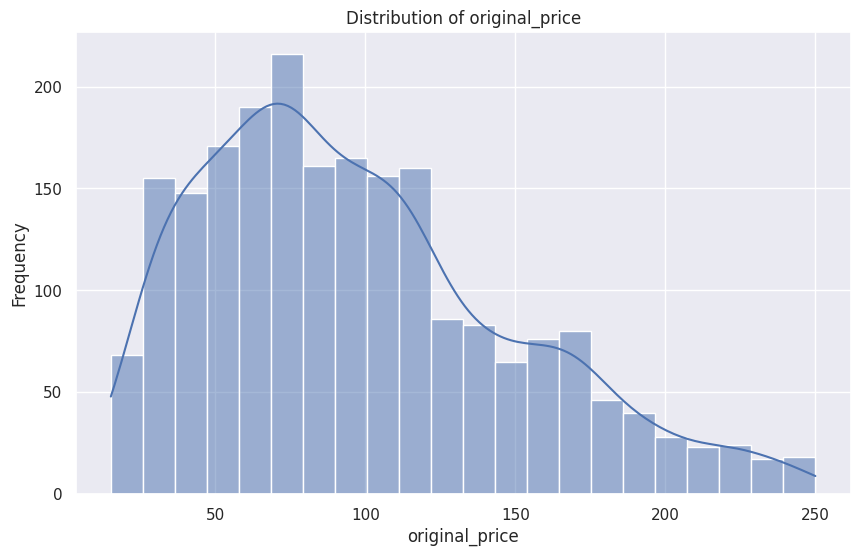

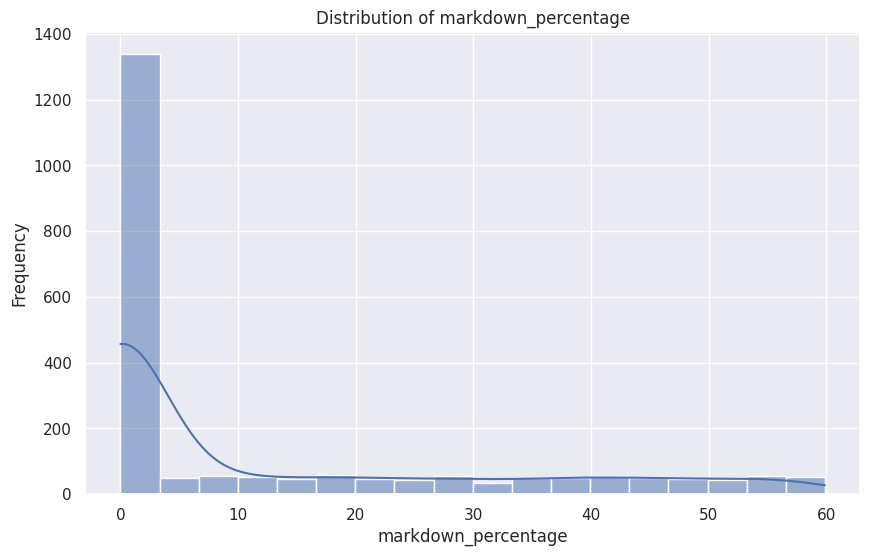

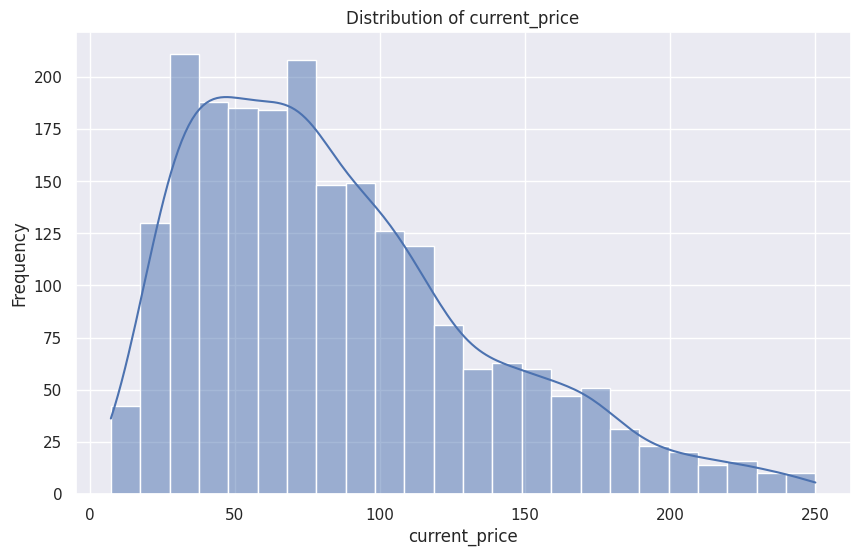

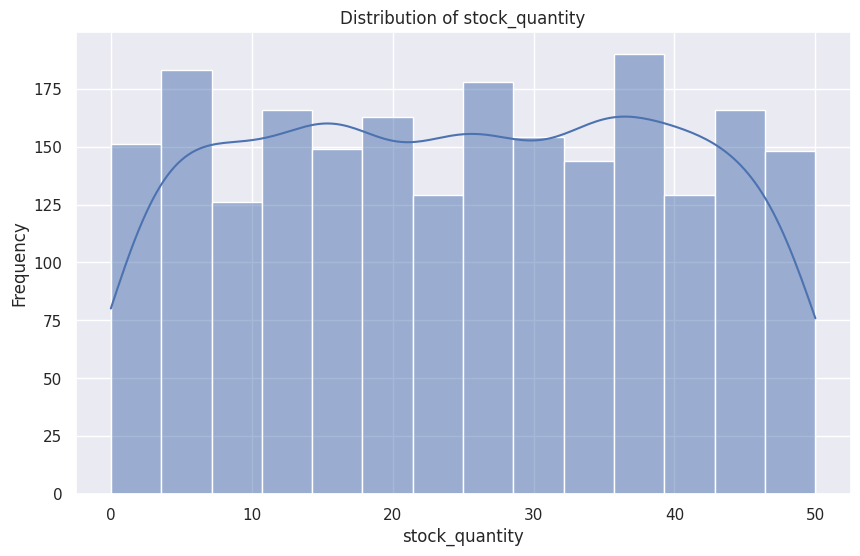

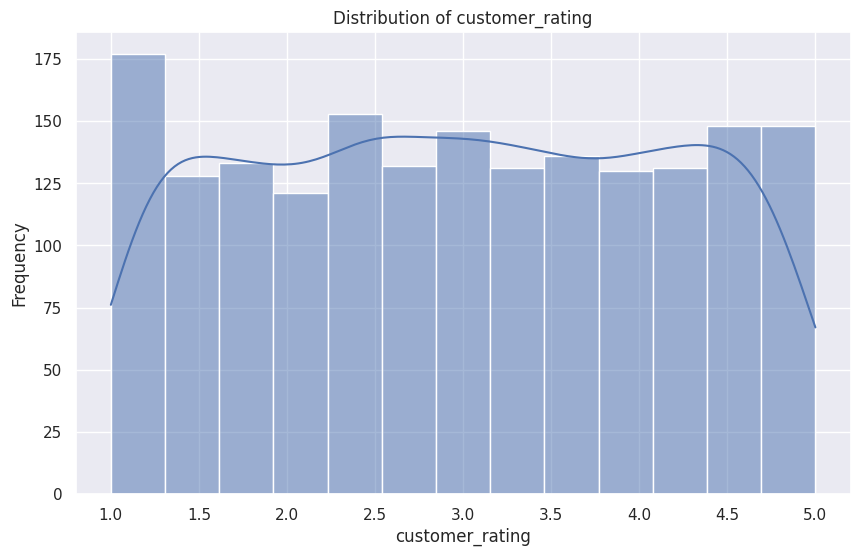

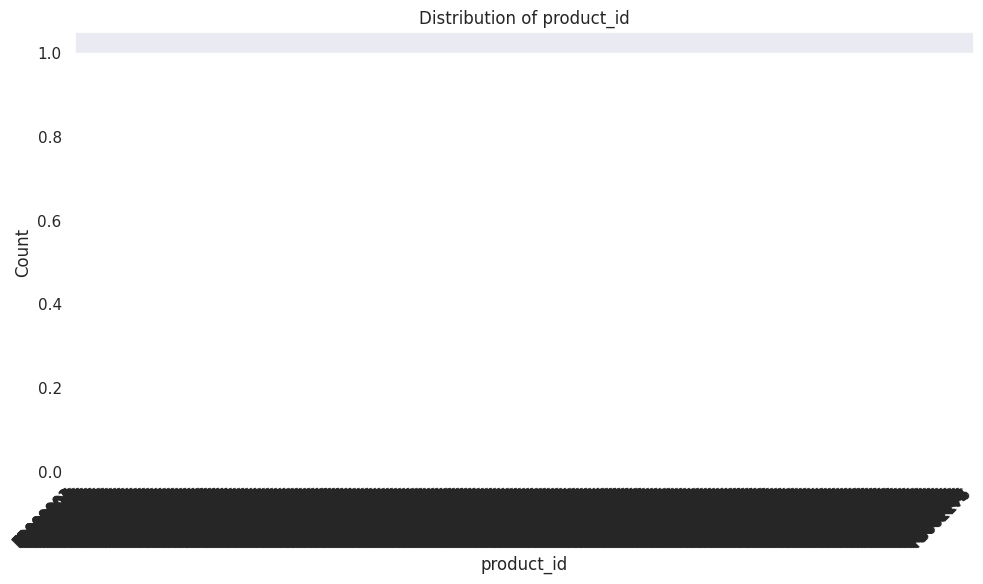

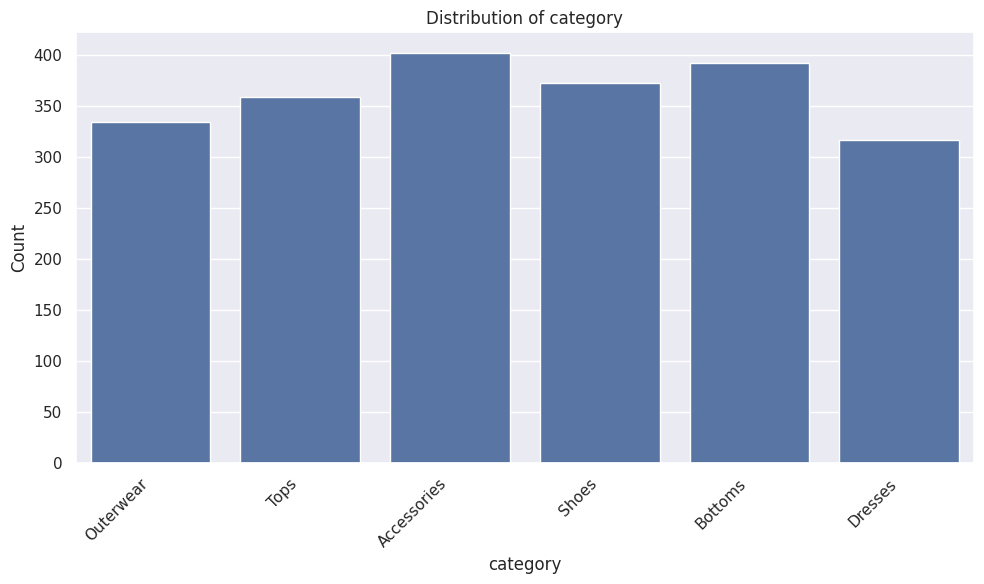

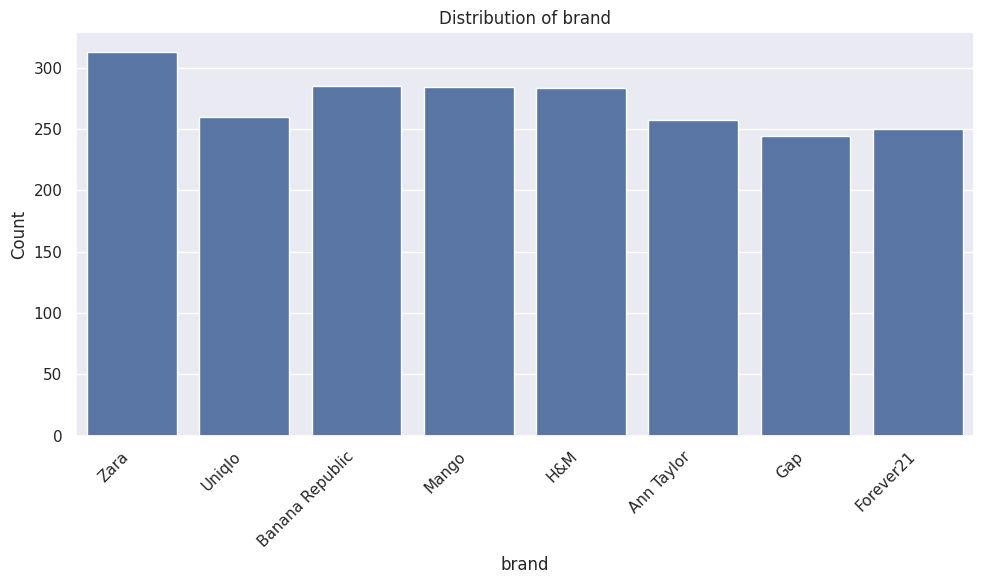

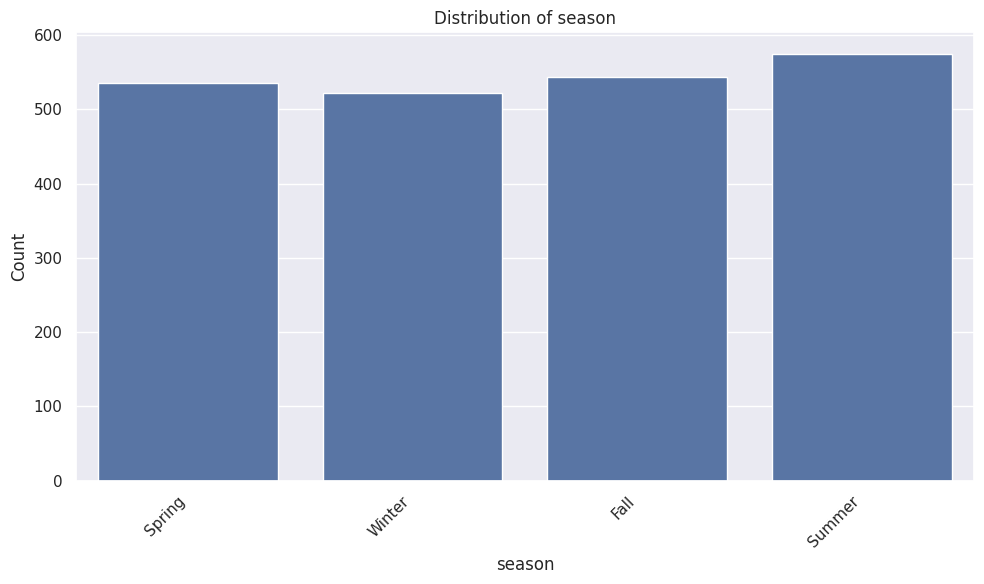

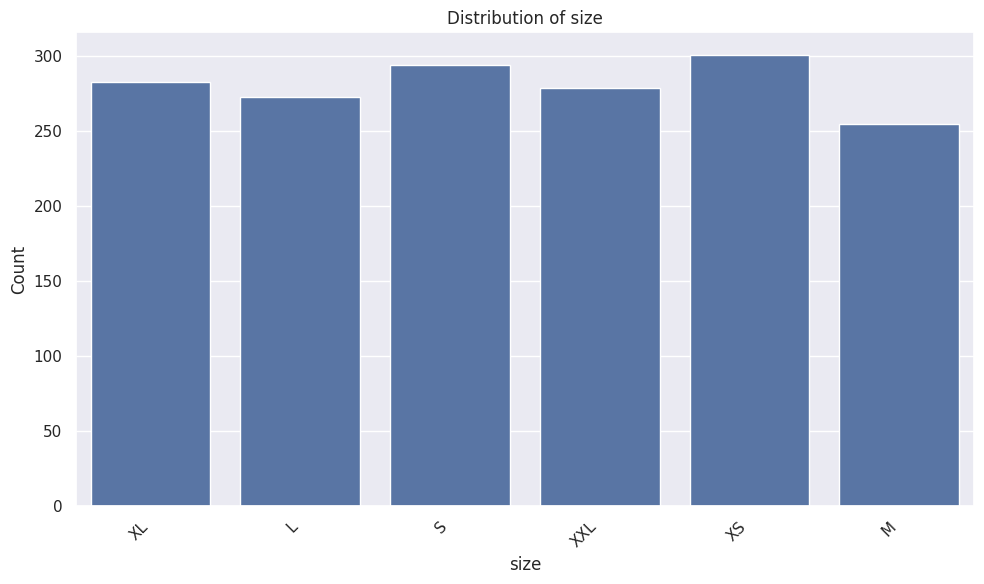

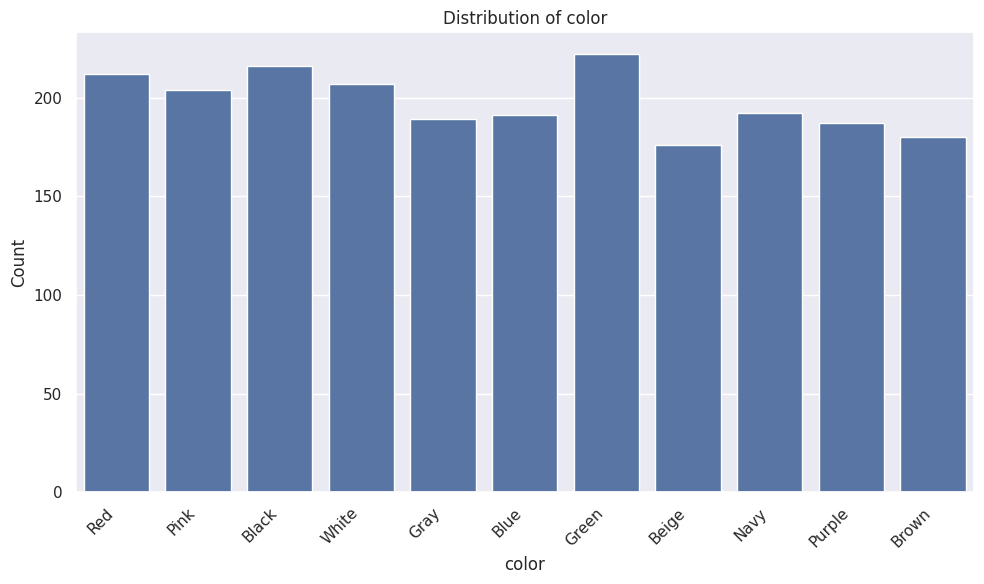

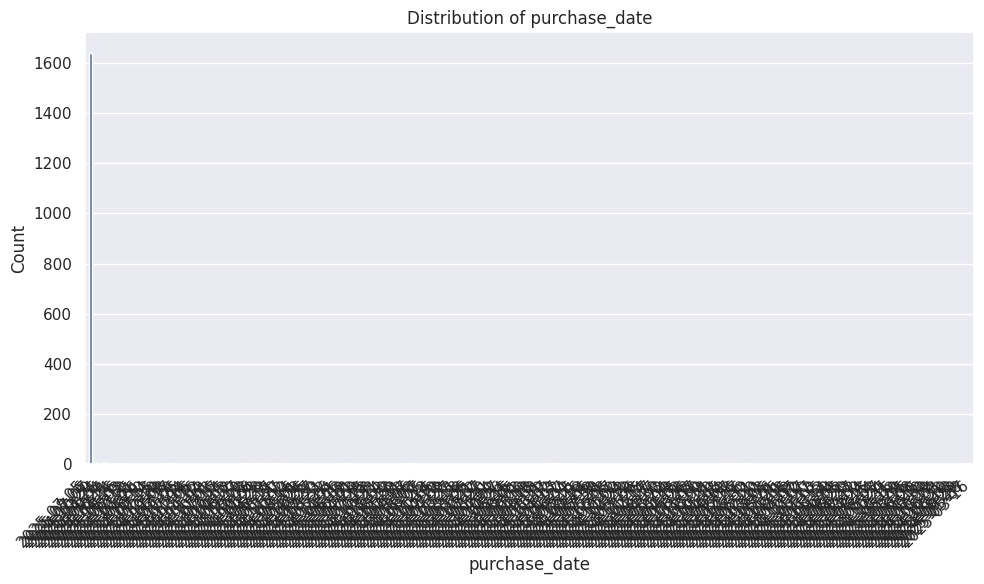

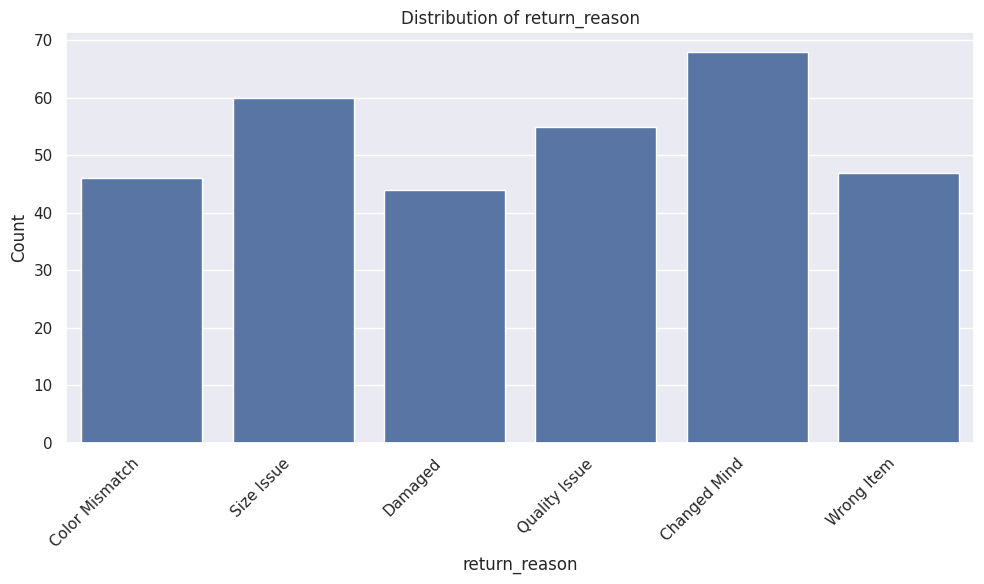

Value counts for product_id:
product_id
FB002160    1
FB002159    1
FB002158    1
FB002157    1
FB002156    1
           ..
FB000005    1
FB000004    1
FB000003    1
FB000002    1
FB000001    1
Name: count, Length: 2176, dtype: int64

Value counts for category:
category
Accessories    402
Bottoms        392
Shoes          372
Tops           359
Outerwear      334
Dresses        317
Name: count, dtype: int64

Value counts for brand:
brand
Zara               313
Banana Republic    285
Mango              284
H&M                283
Uniqlo             260
Ann Taylor         257
Forever21          250
Gap                244
Name: count, dtype: int64

Value counts for season:
season
Summer    575
Fall      544
Spring    535
Winter    522
Name: count, dtype: int64

Value counts for size:
size
XS     301
S      294
XL     283
XXL    279
L      273
M      255
Name: count, dtype: int64

Value counts for color:
color
Green     222
Black     216
Red       212
White     207
Pink      204
Navy      1

In [17]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

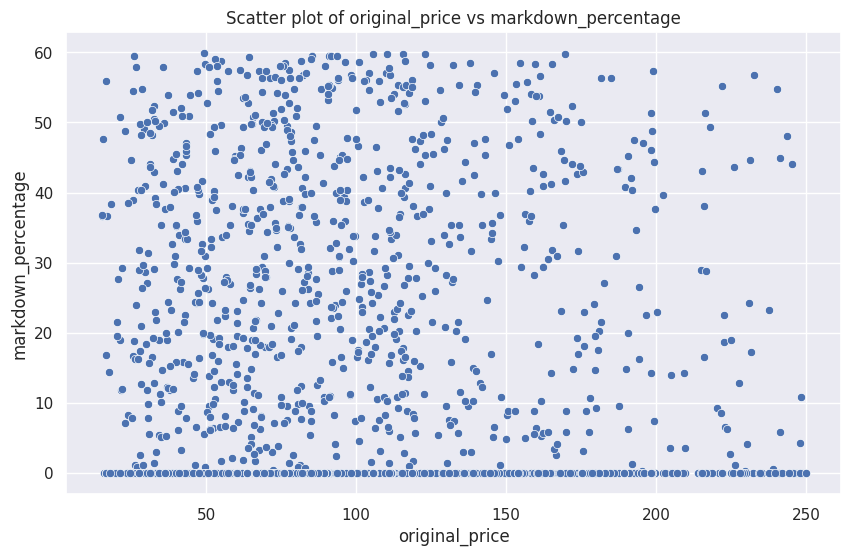

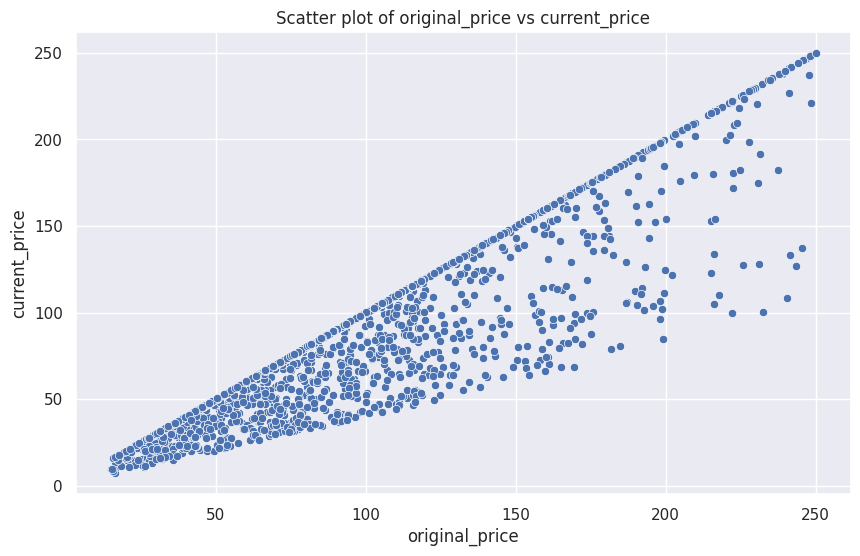

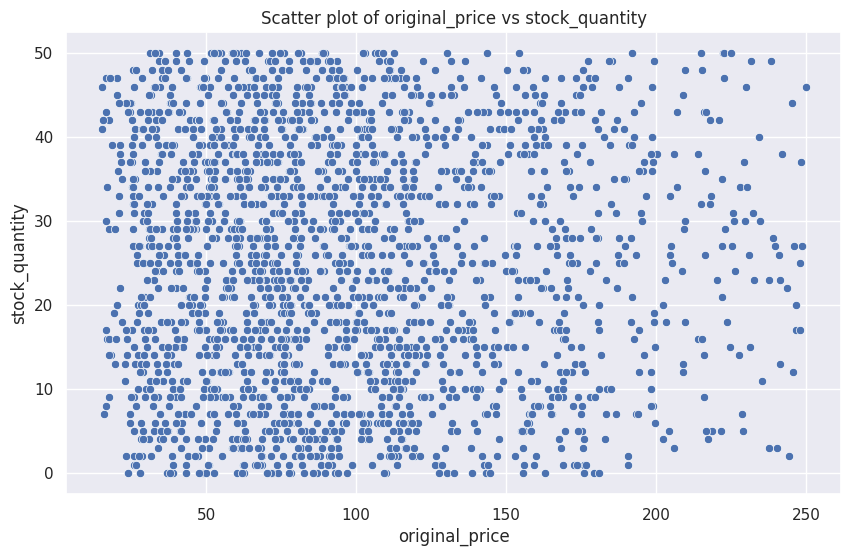

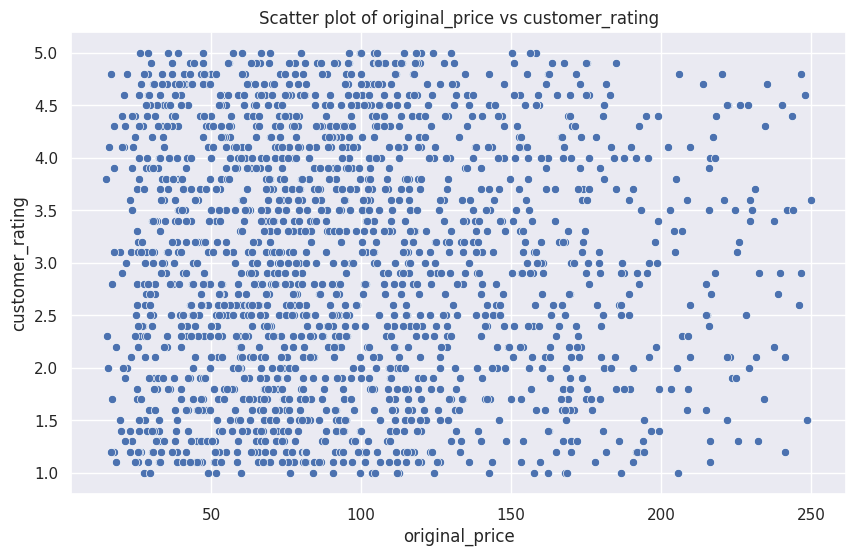

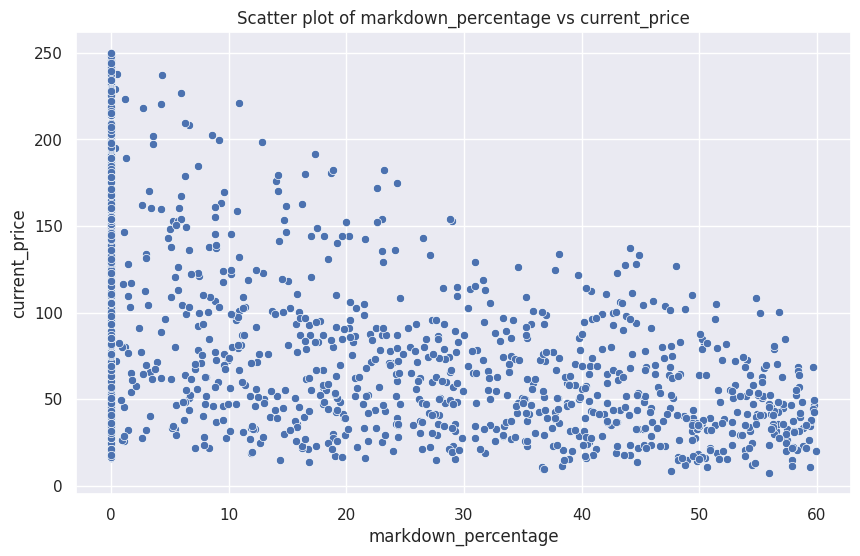

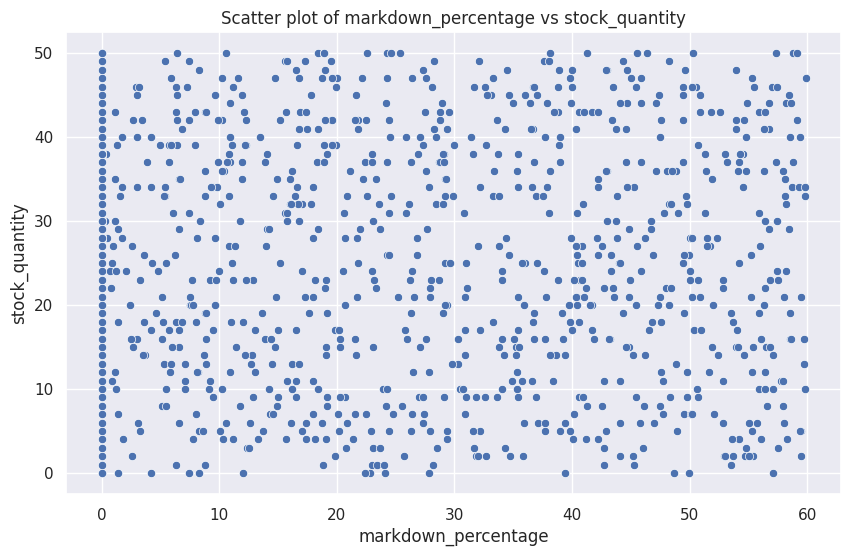

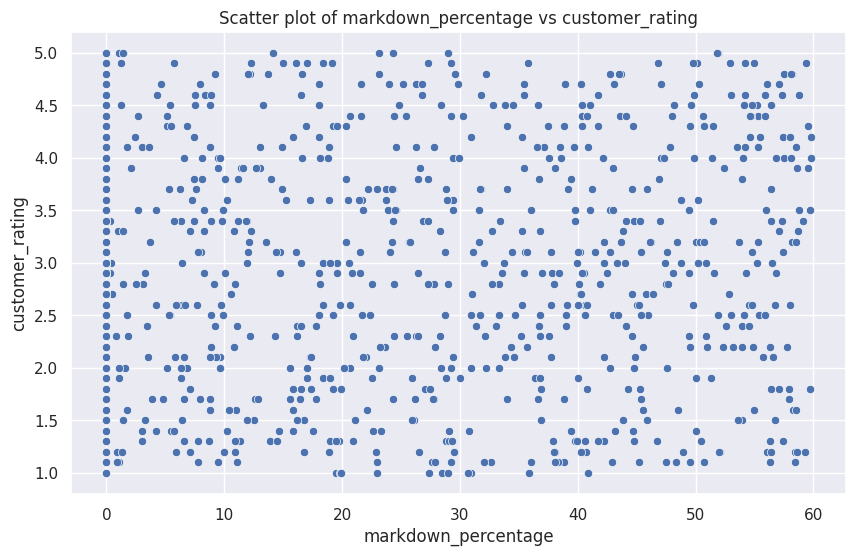

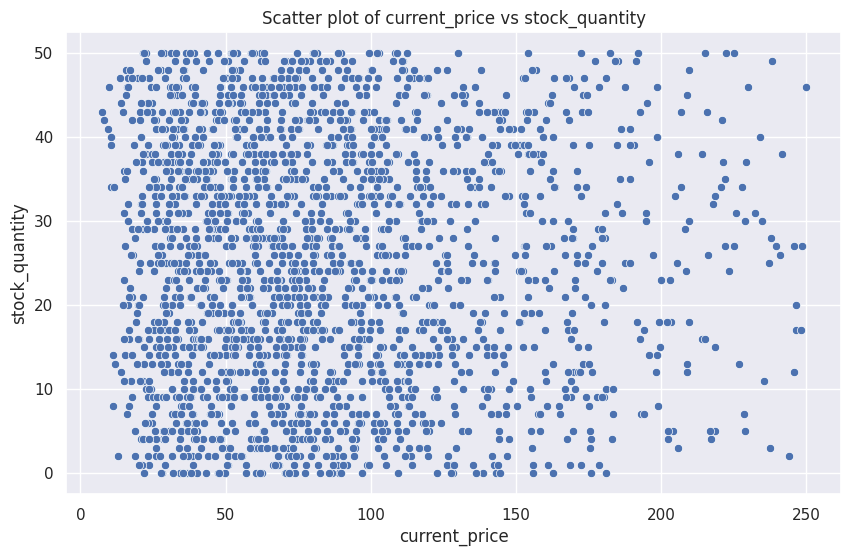

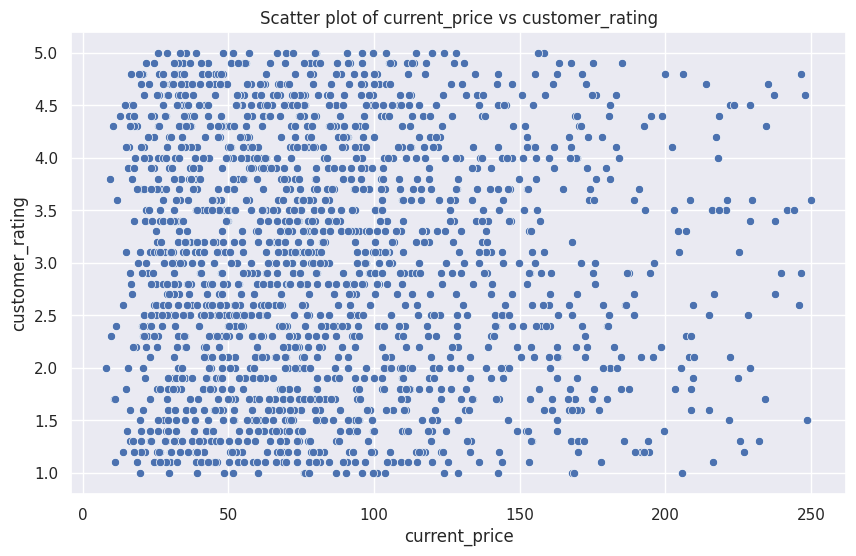

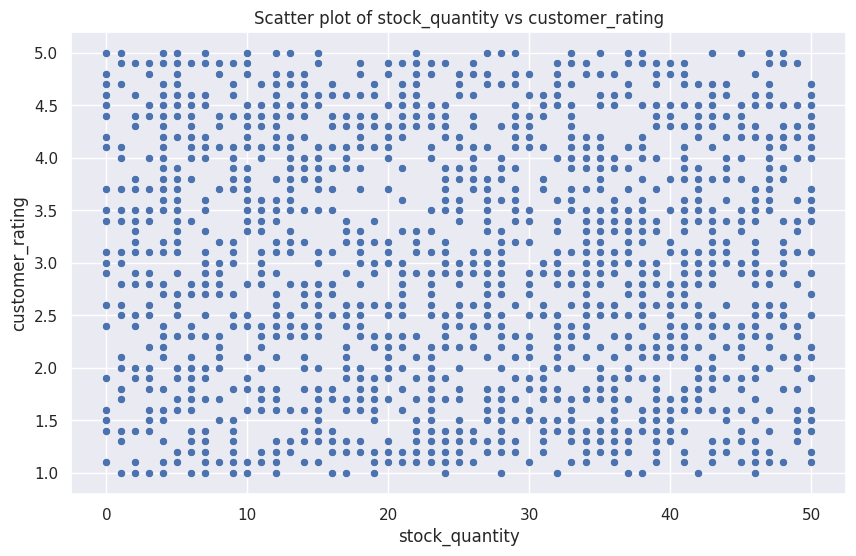

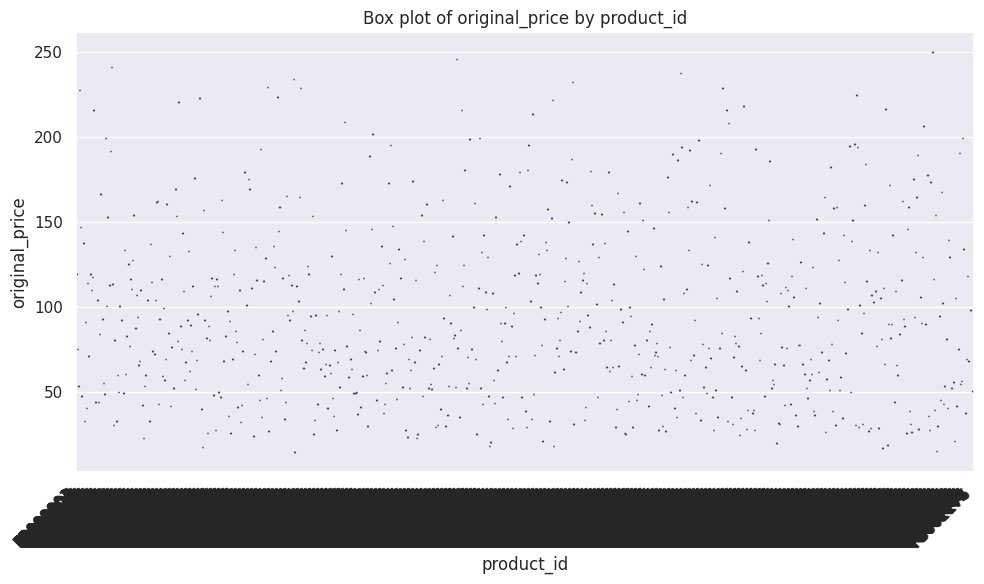

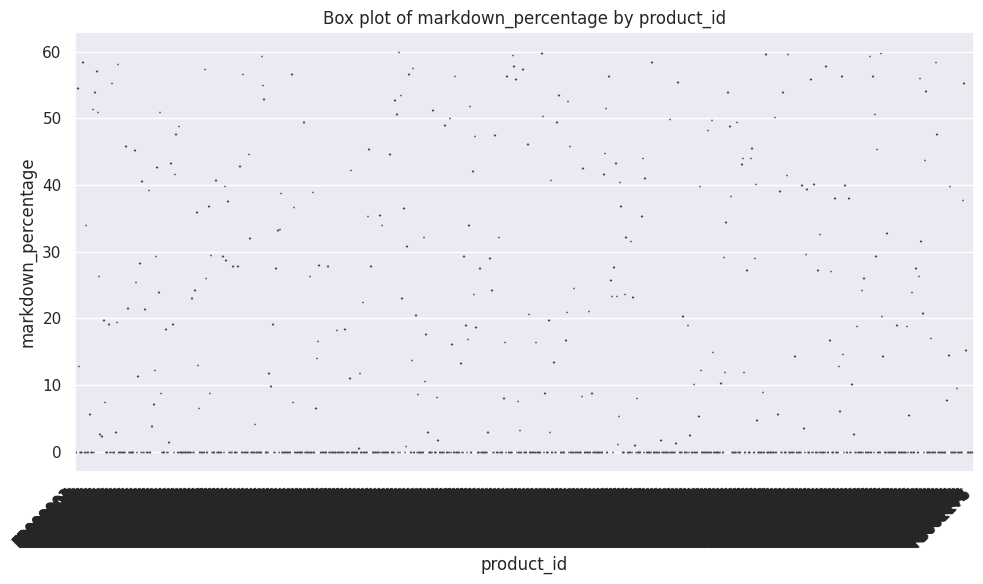

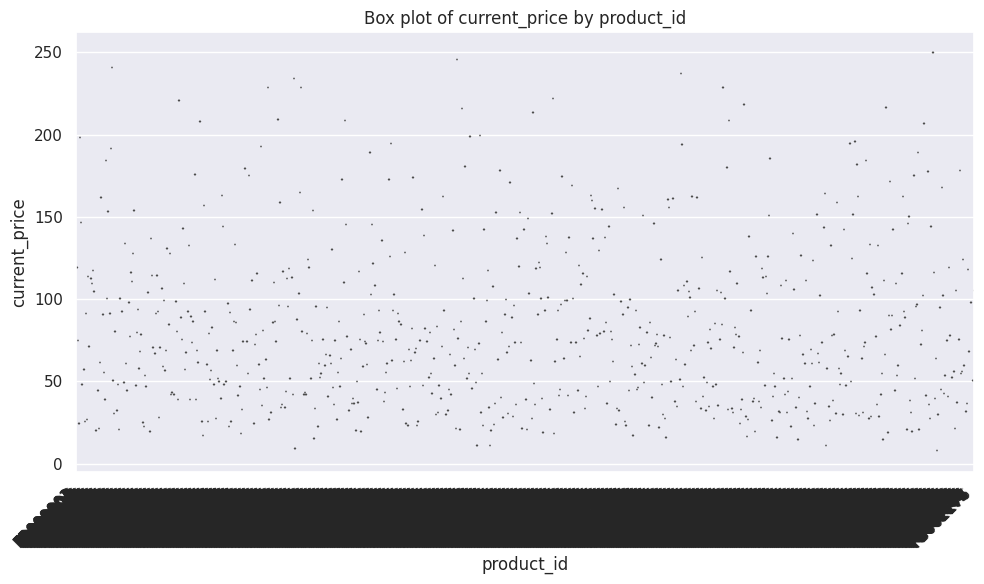

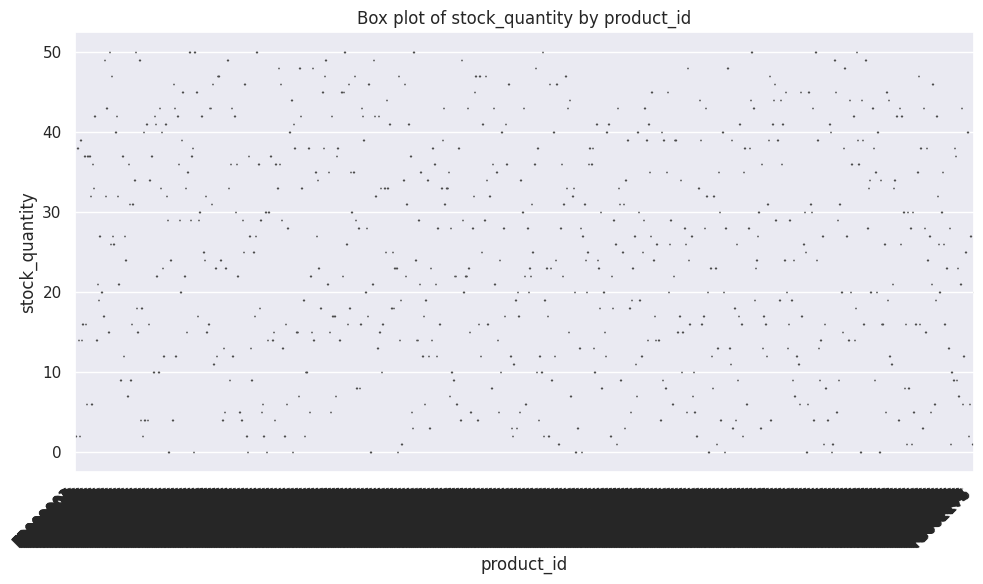

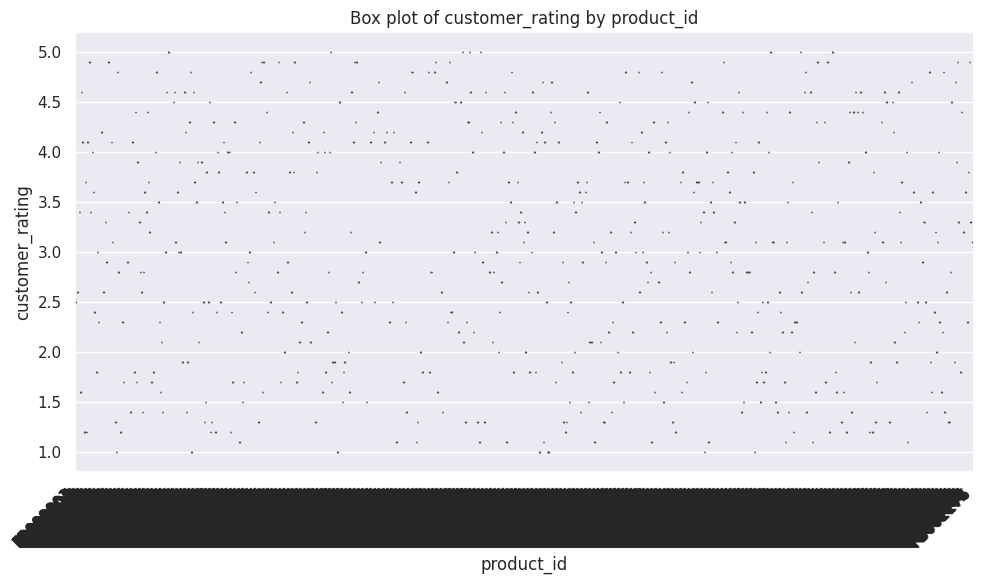

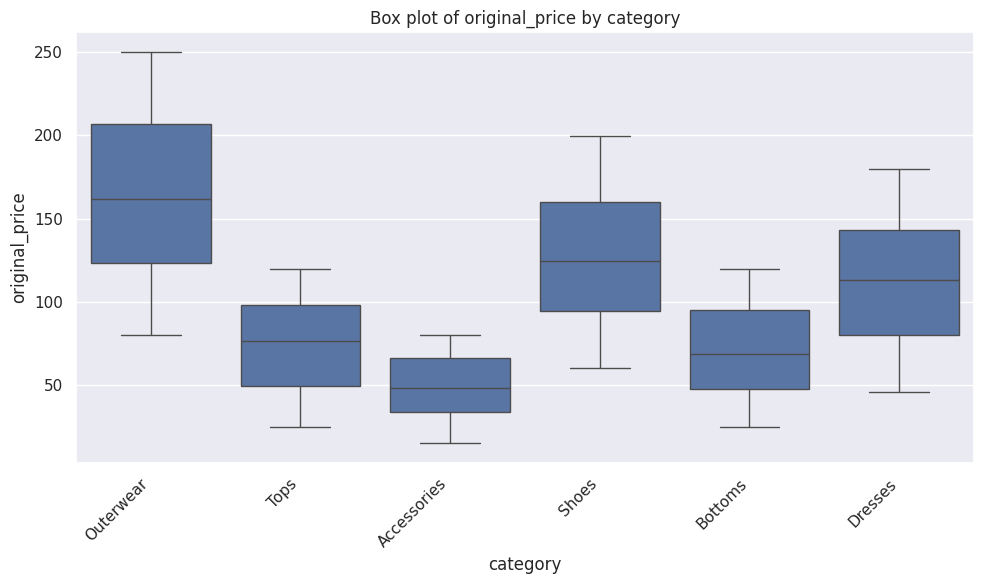

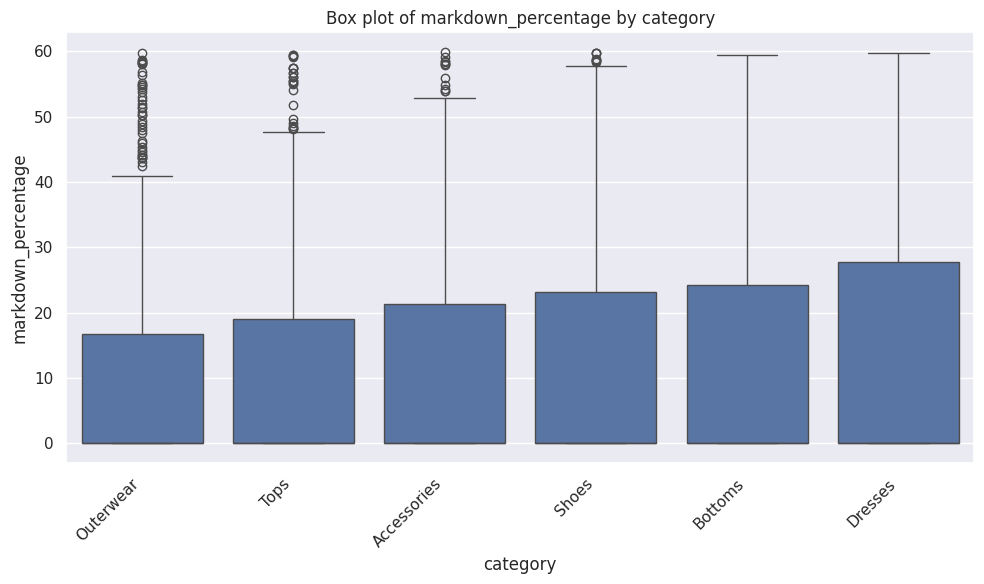

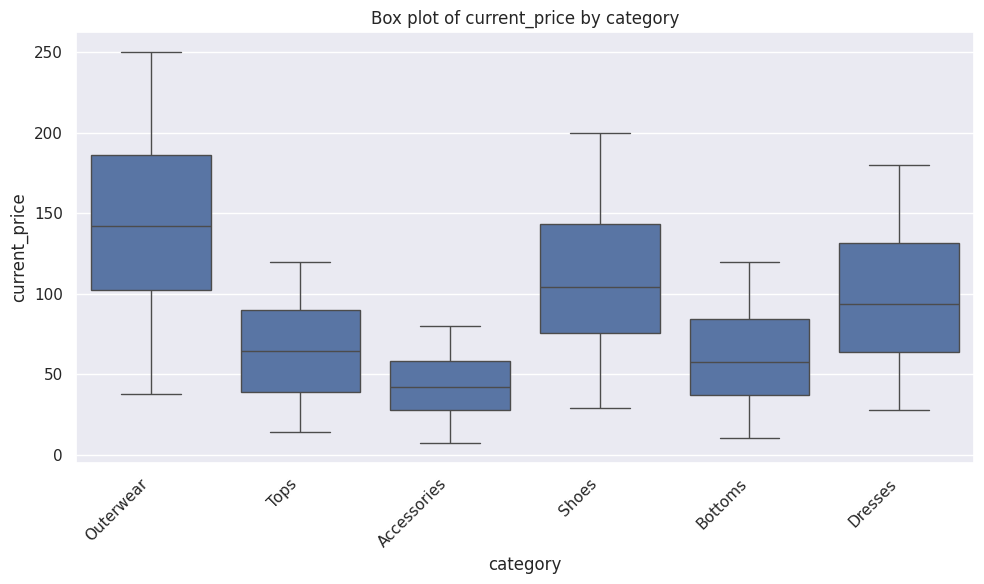

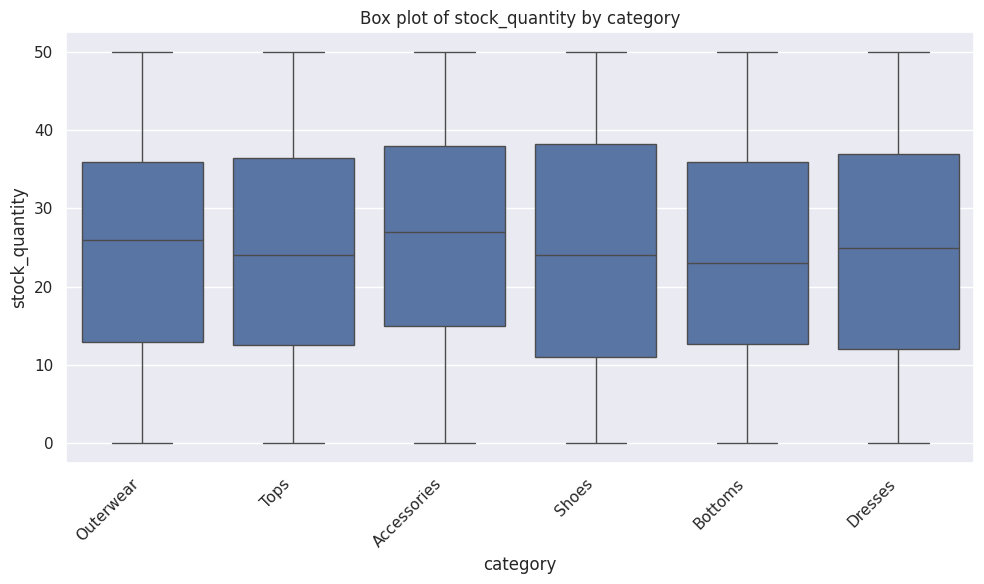

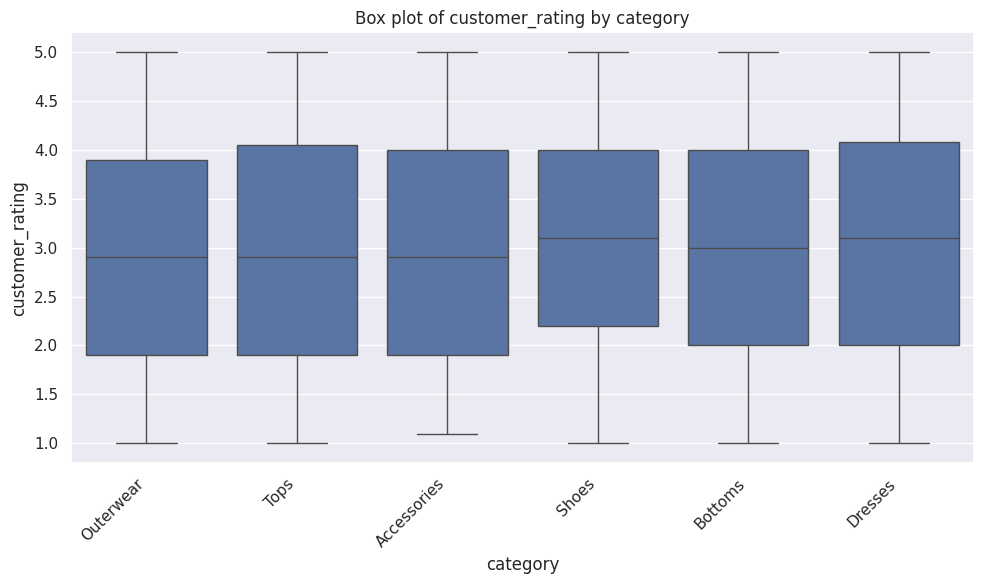

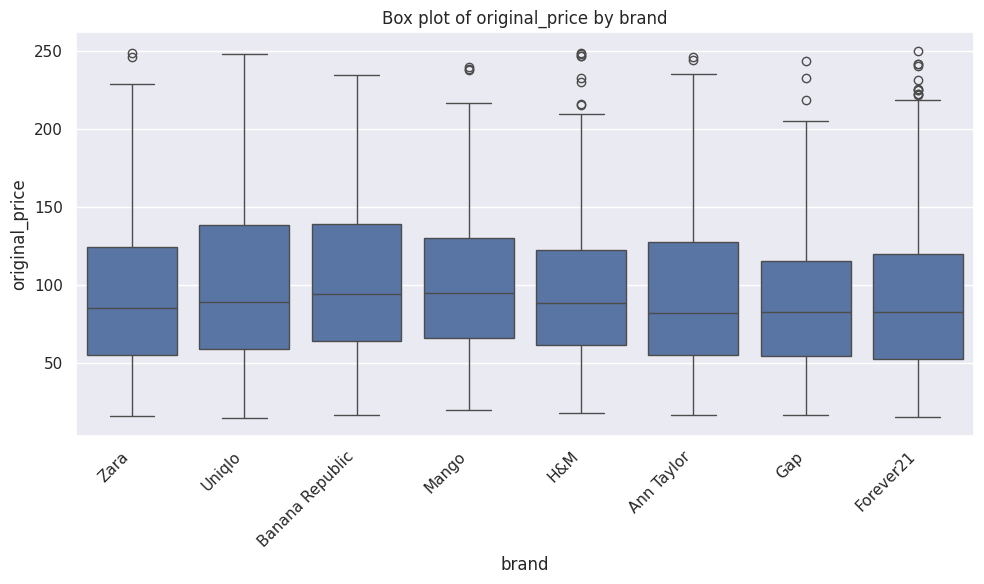

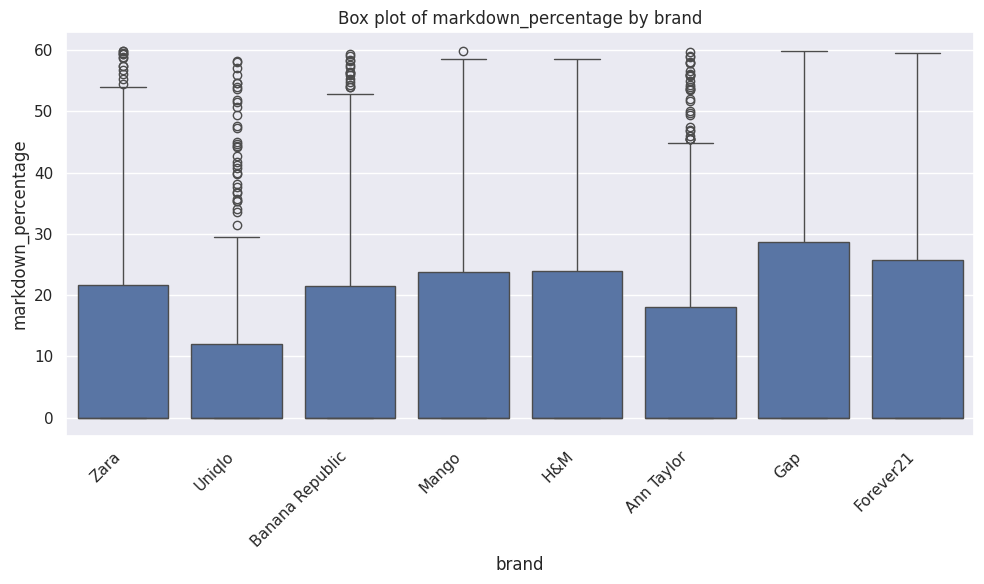

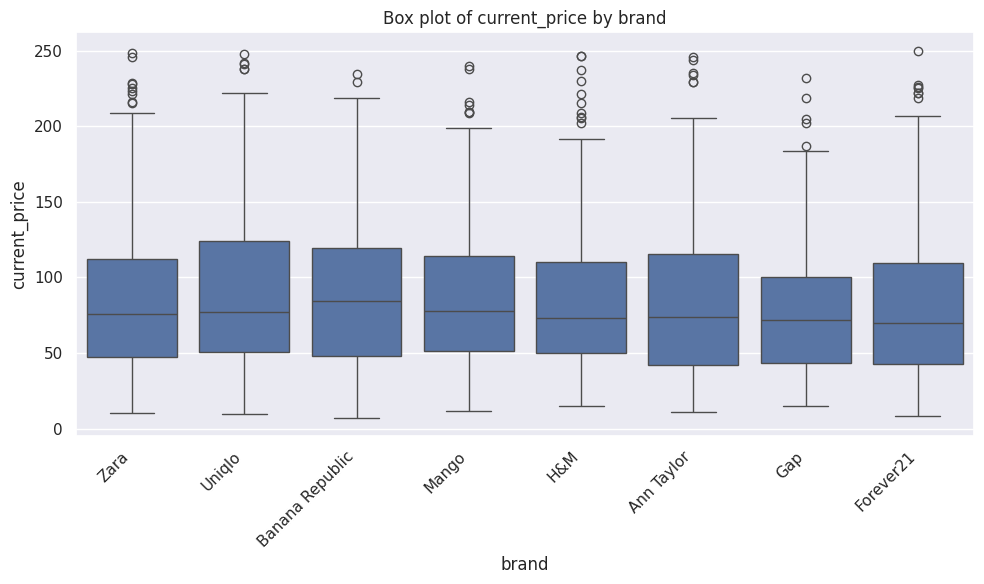

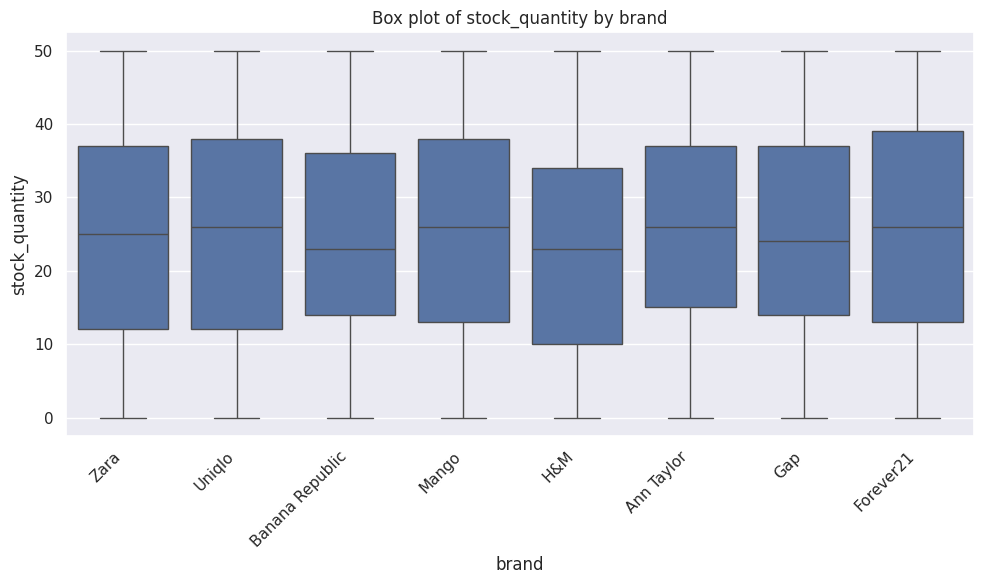

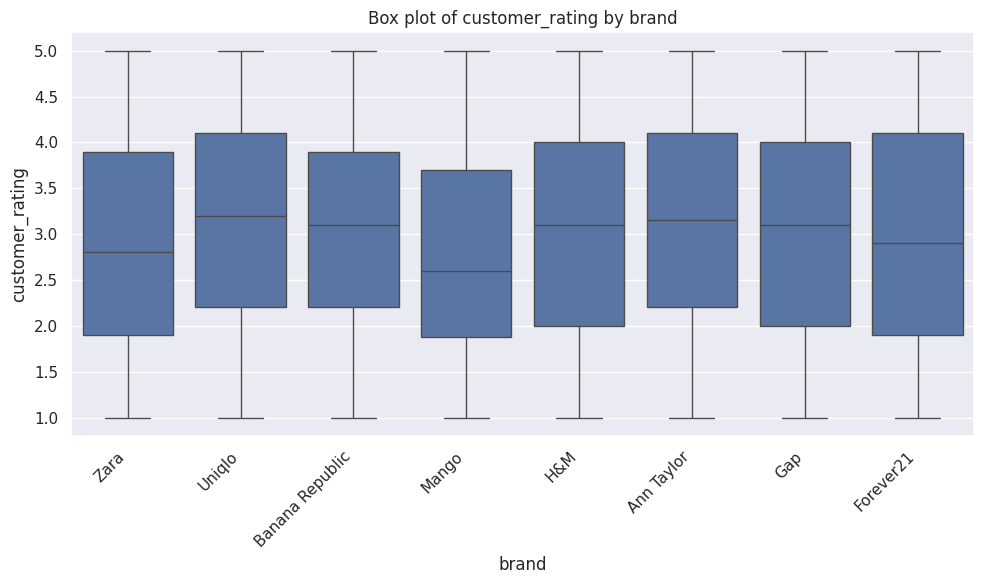

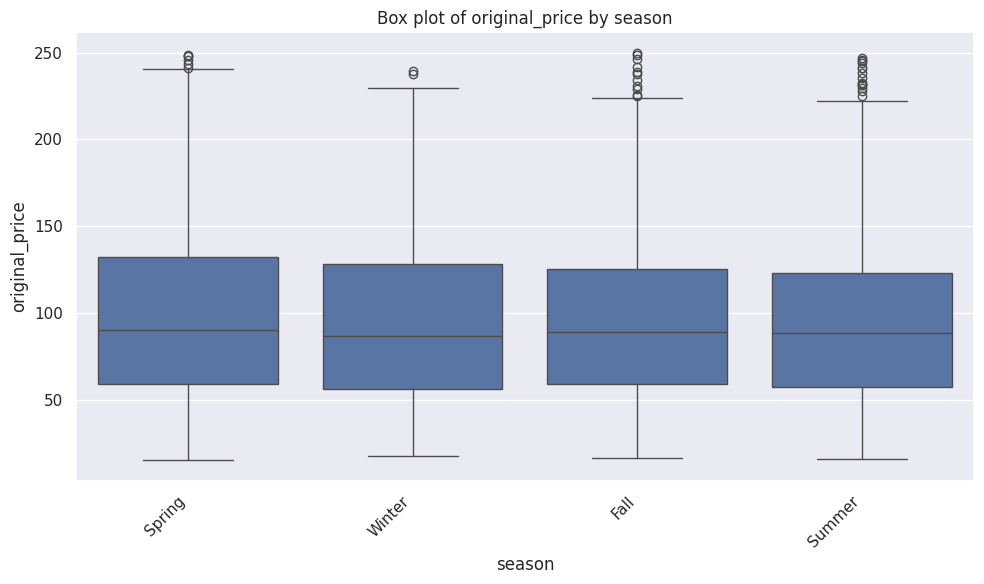

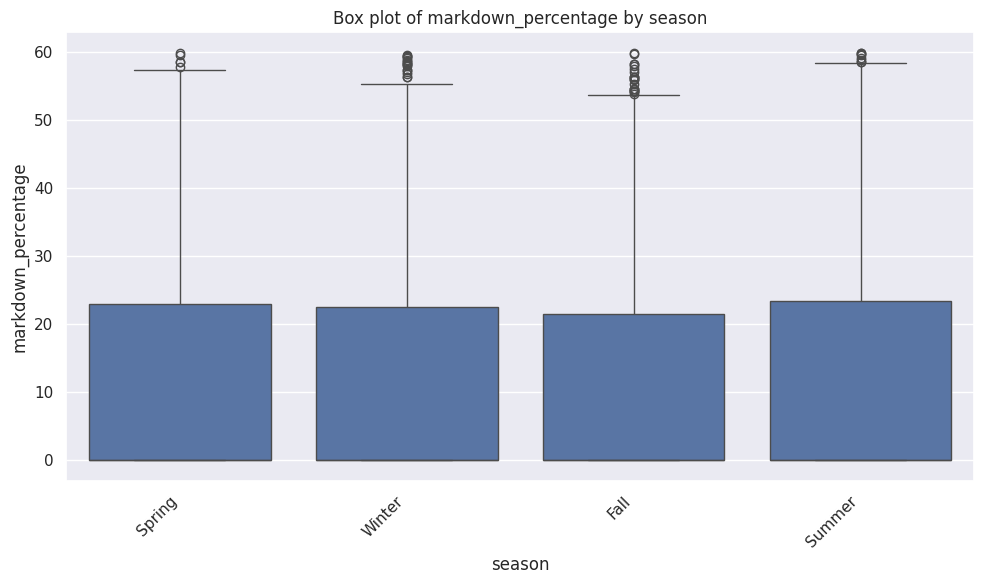

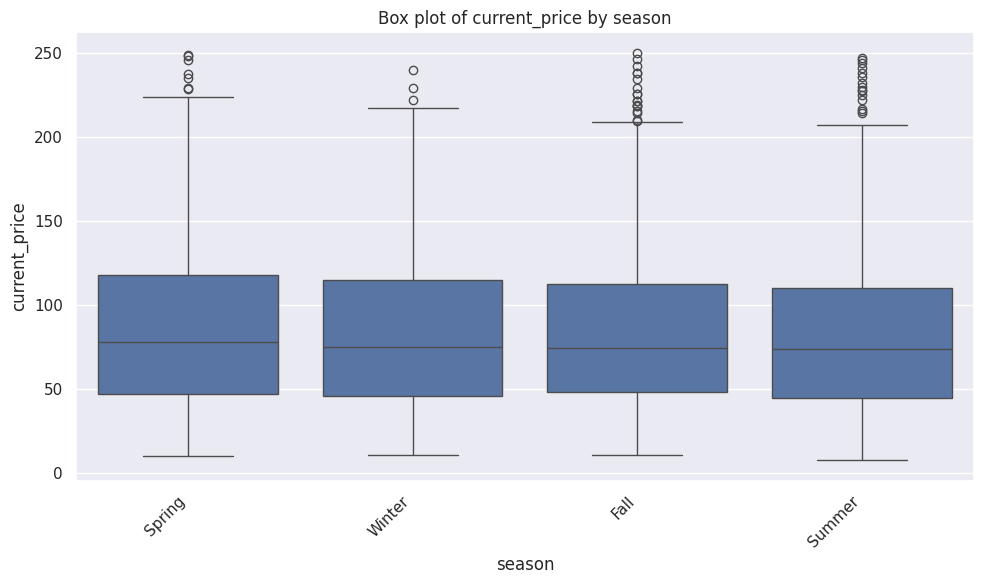

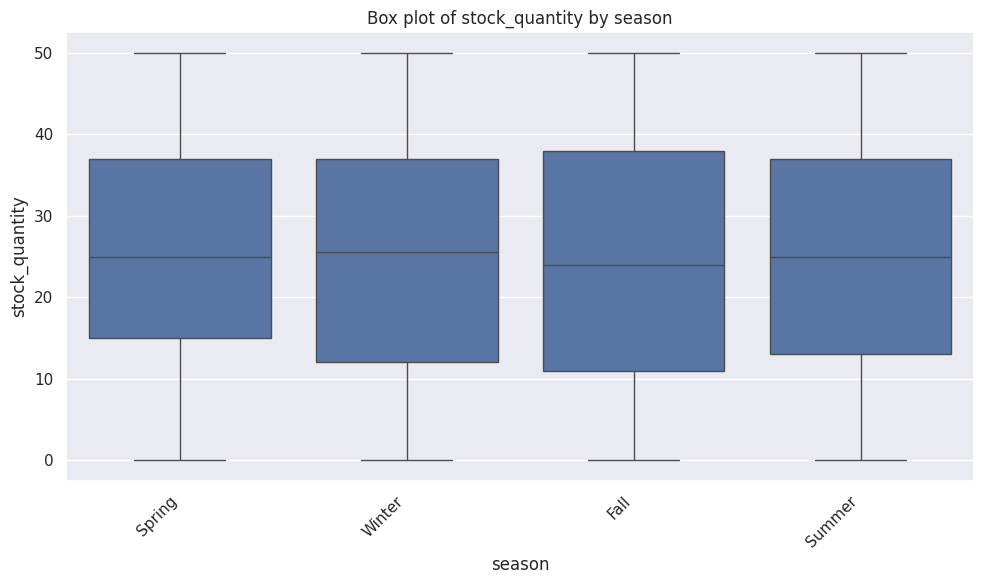

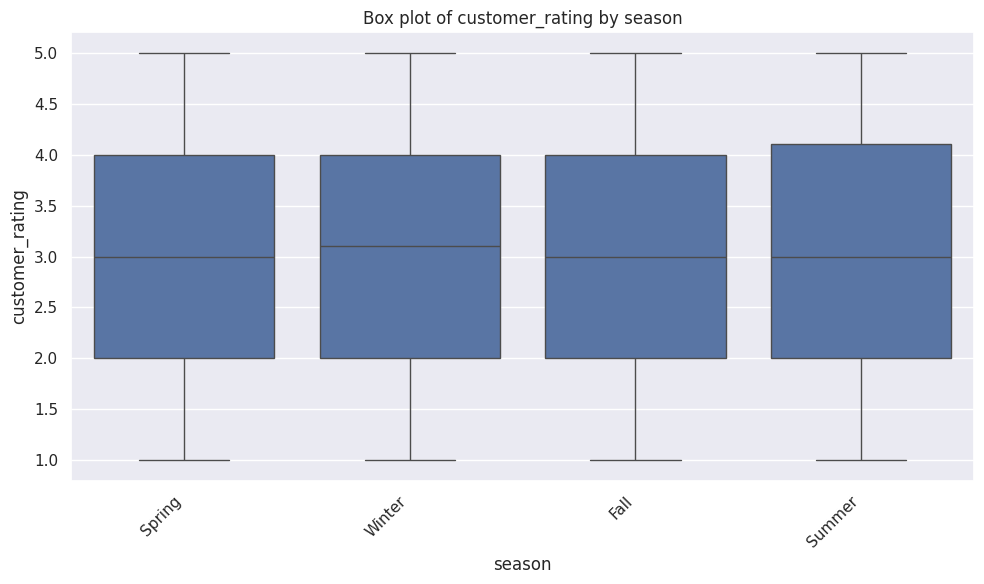

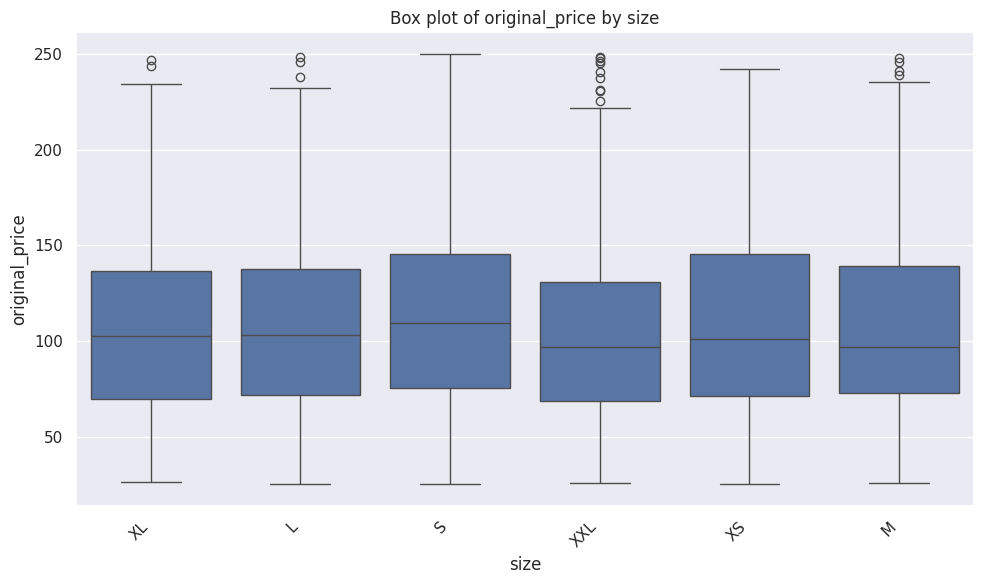

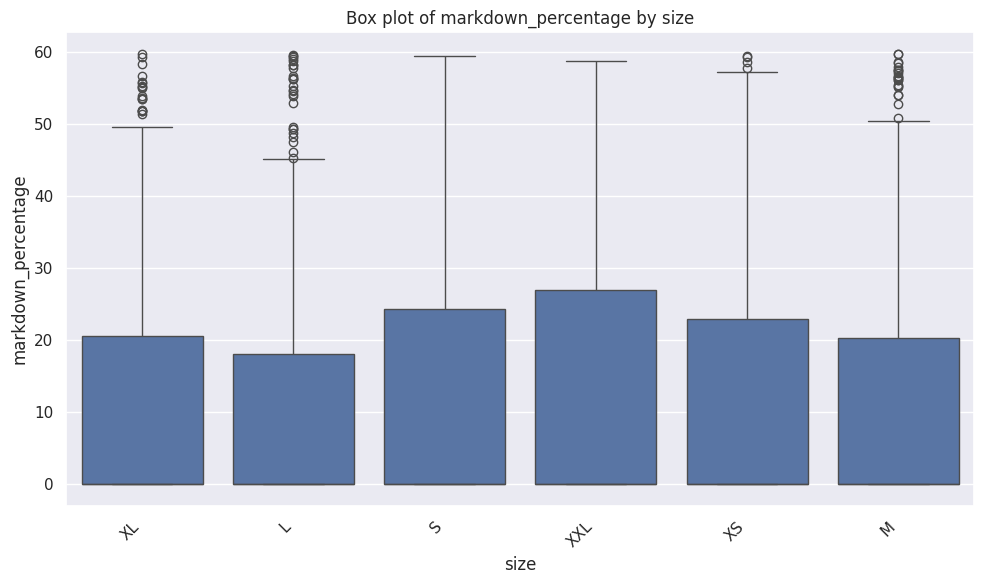

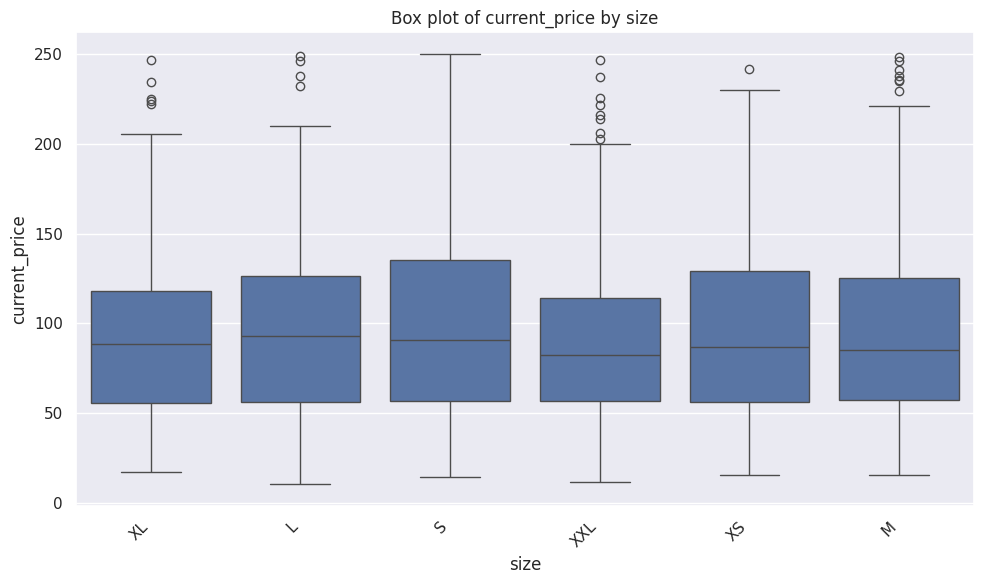

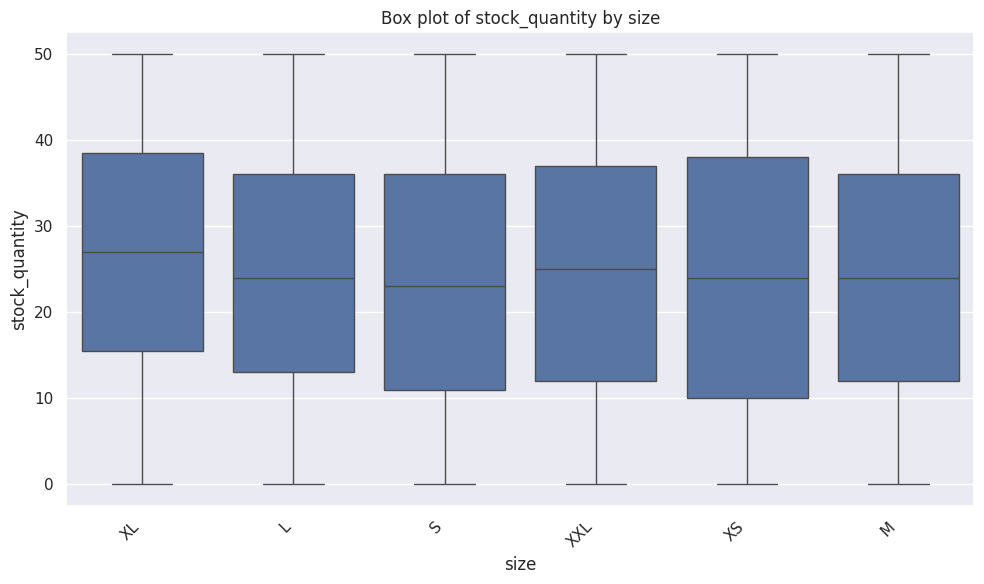

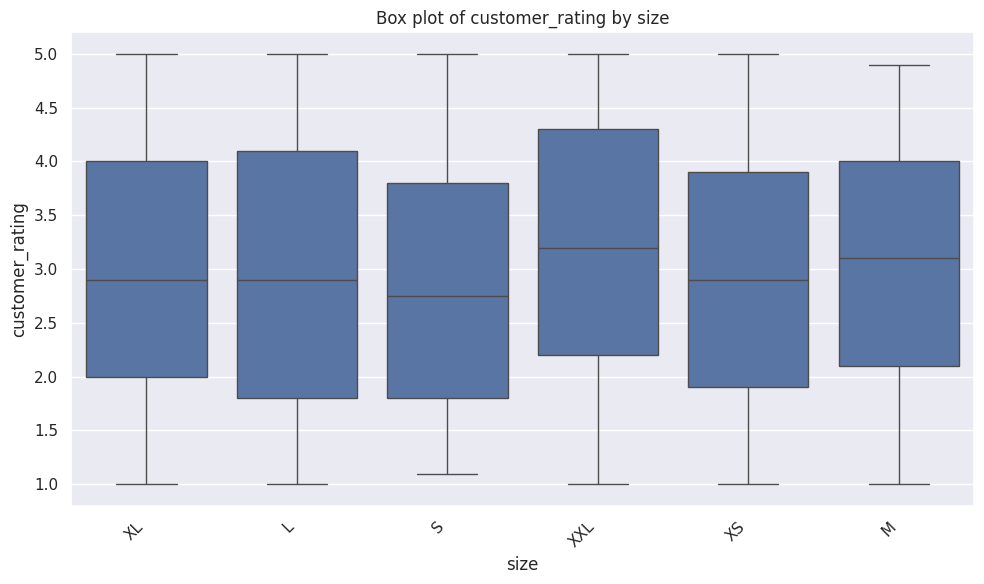

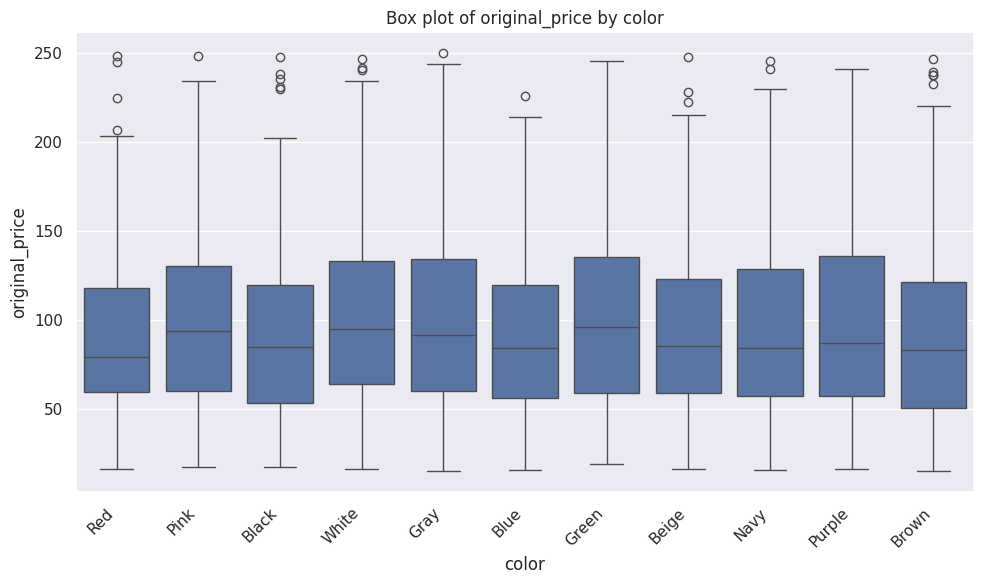

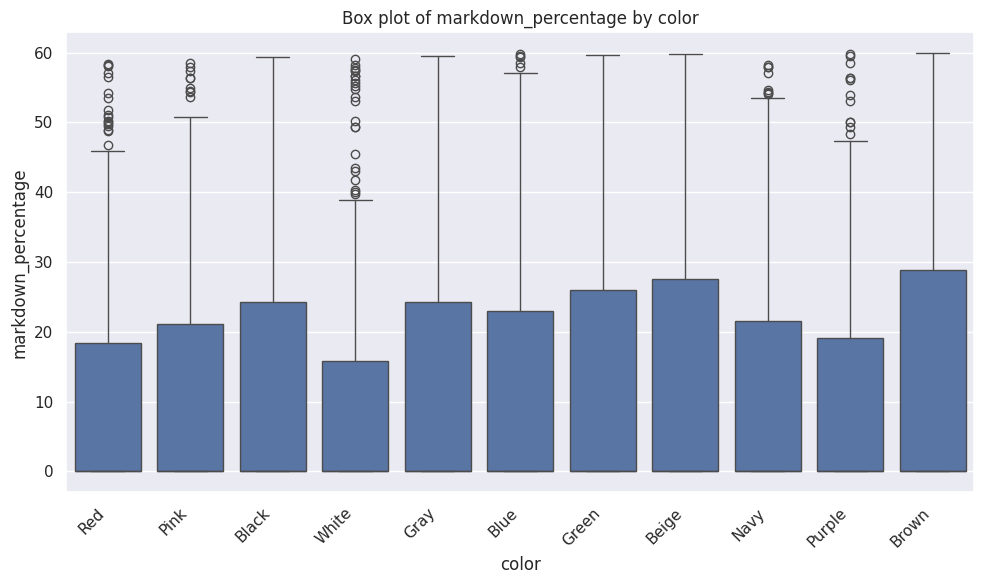

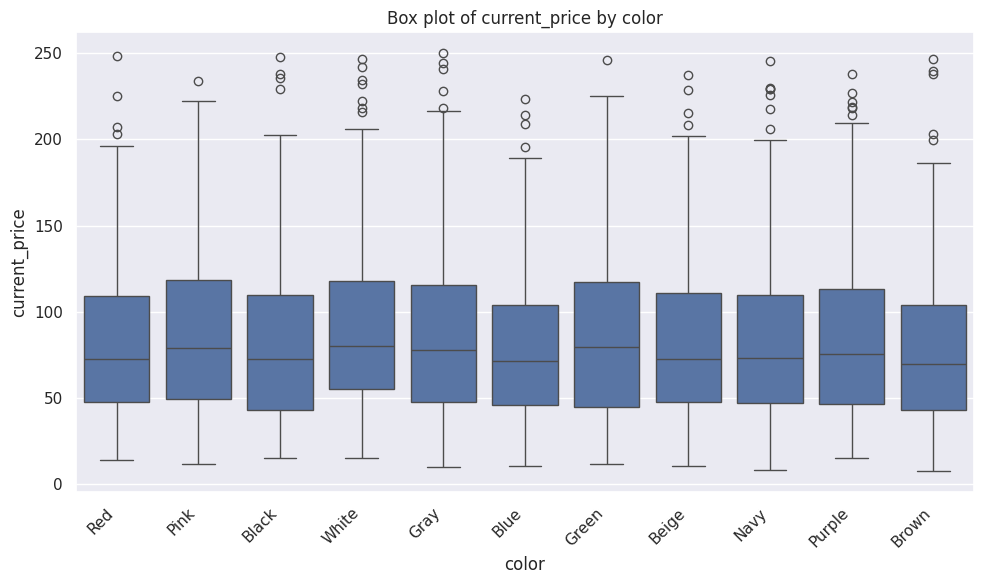

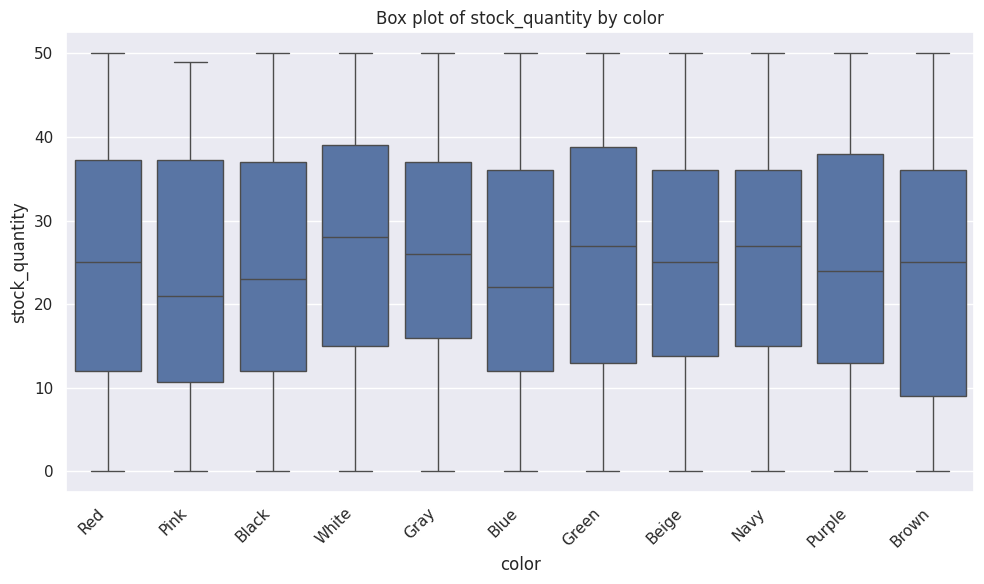

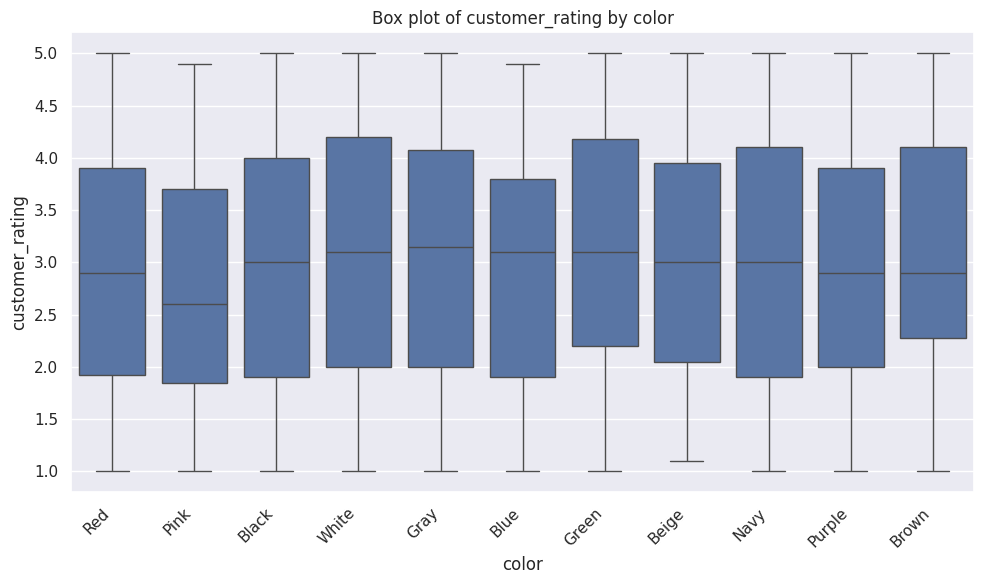

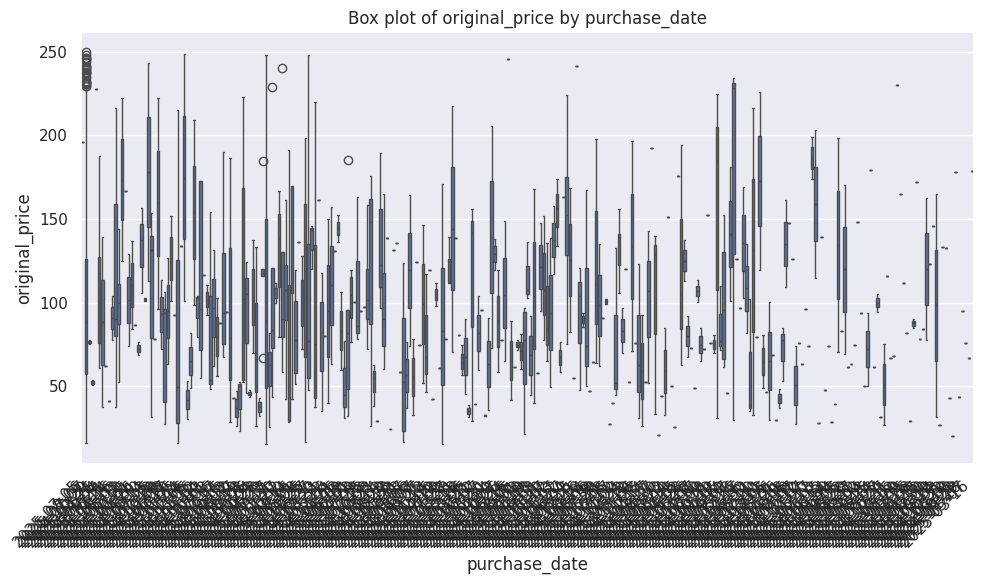

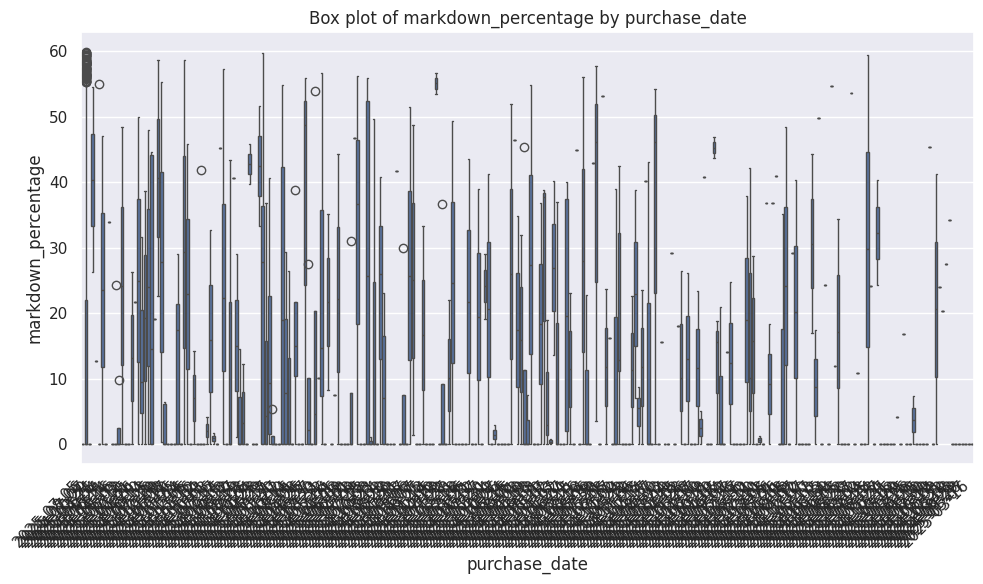

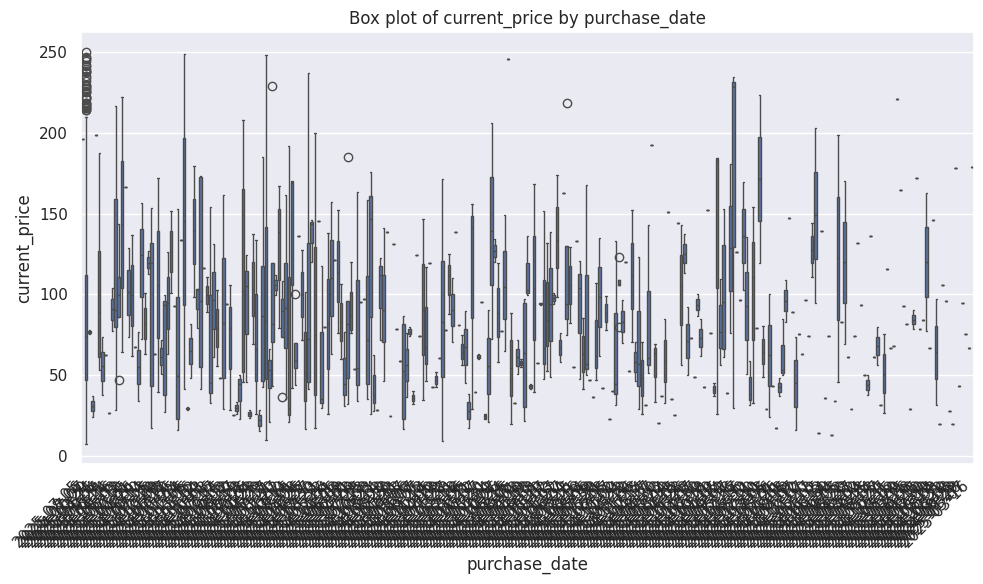

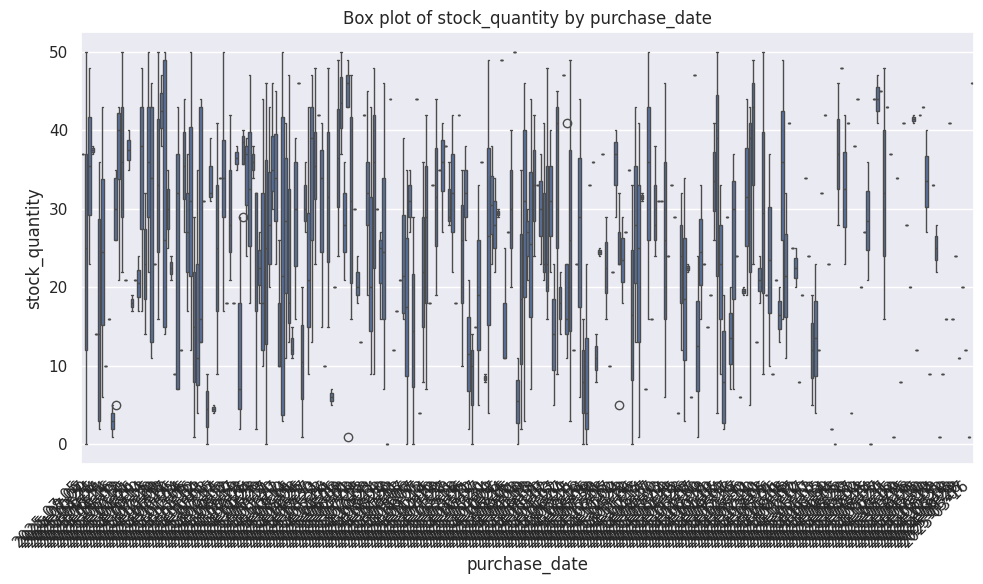

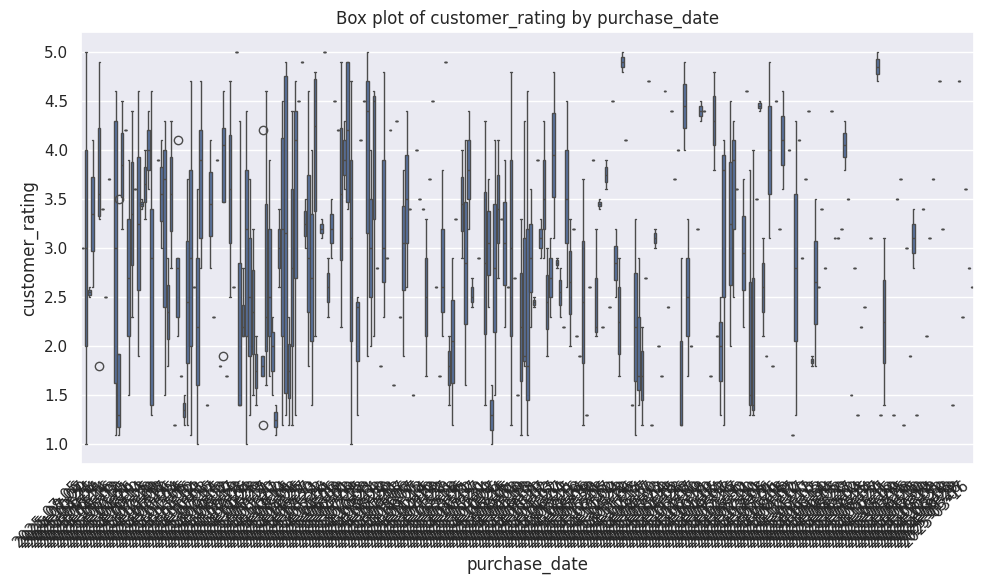

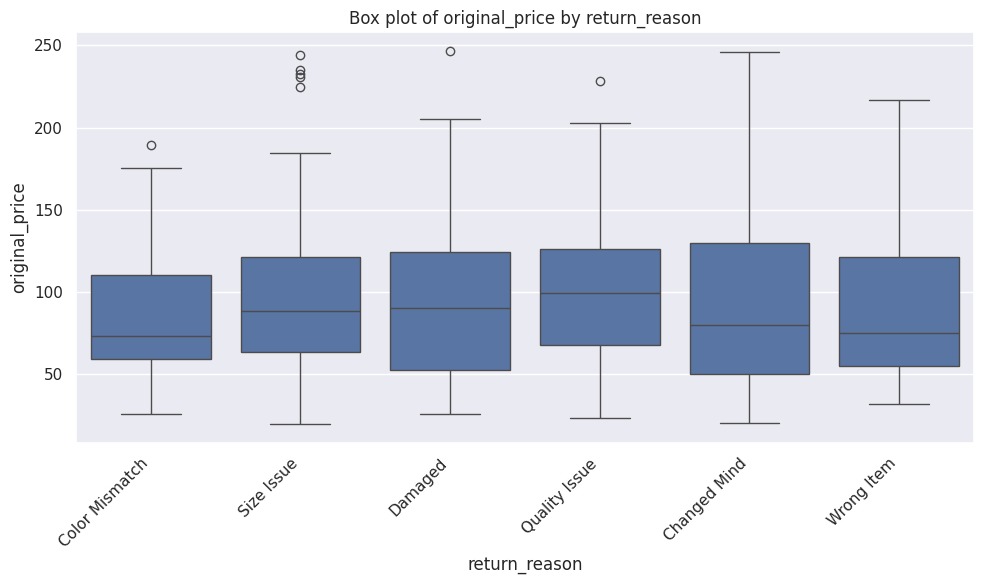

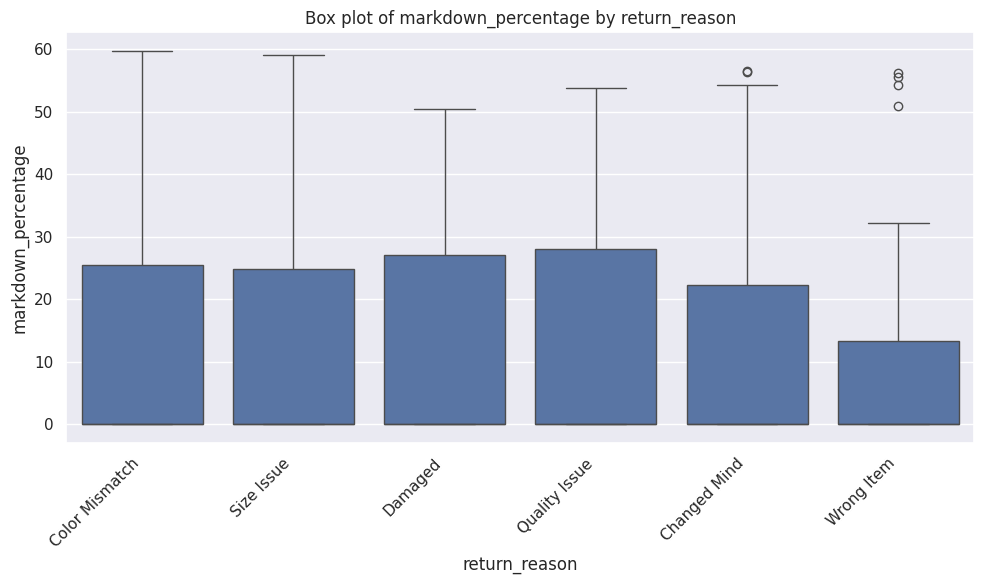

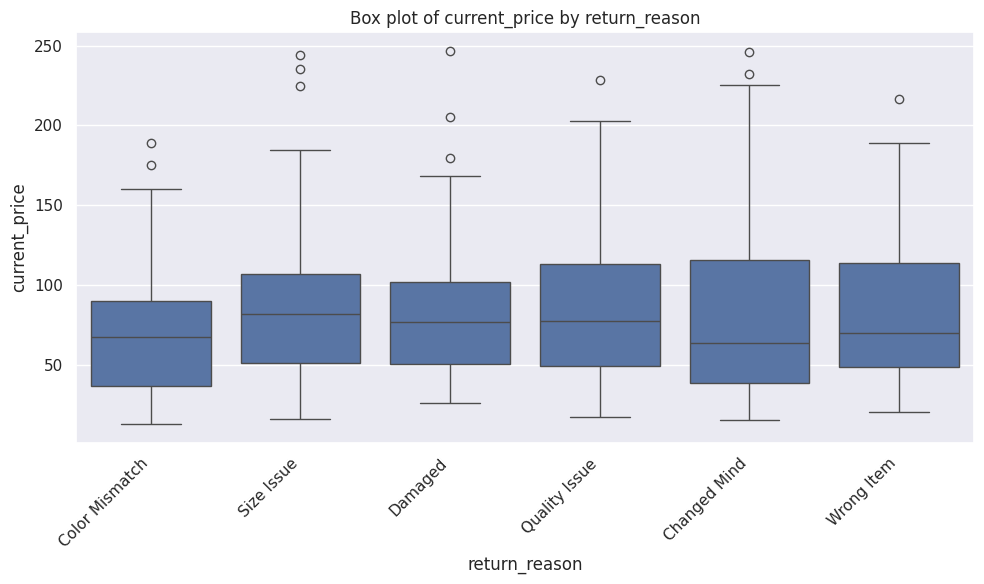

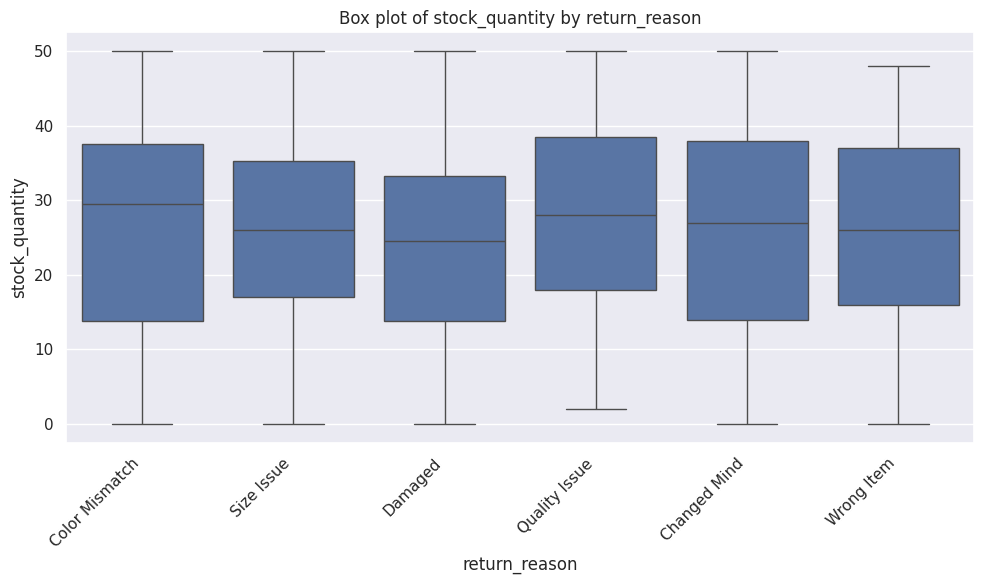

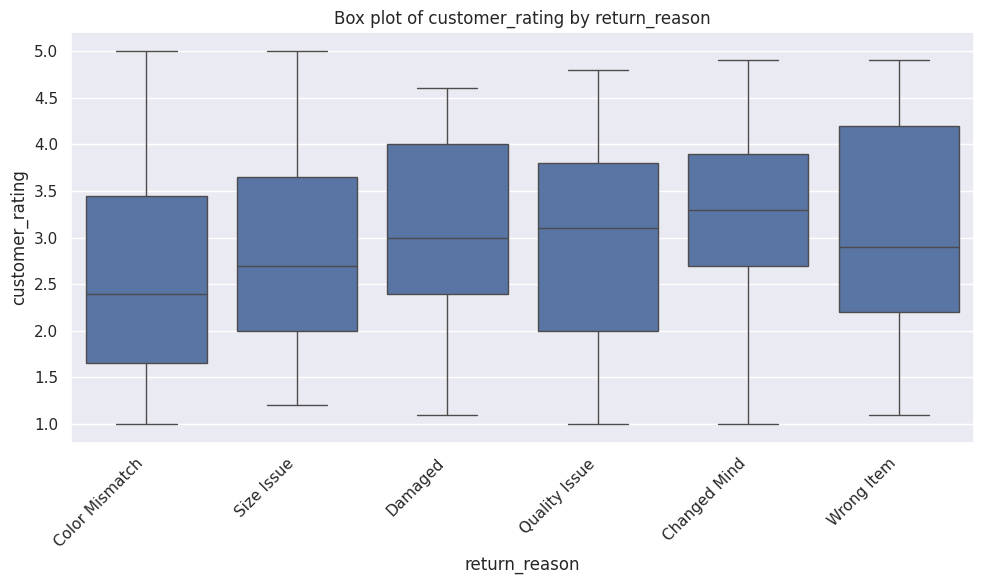

In [18]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

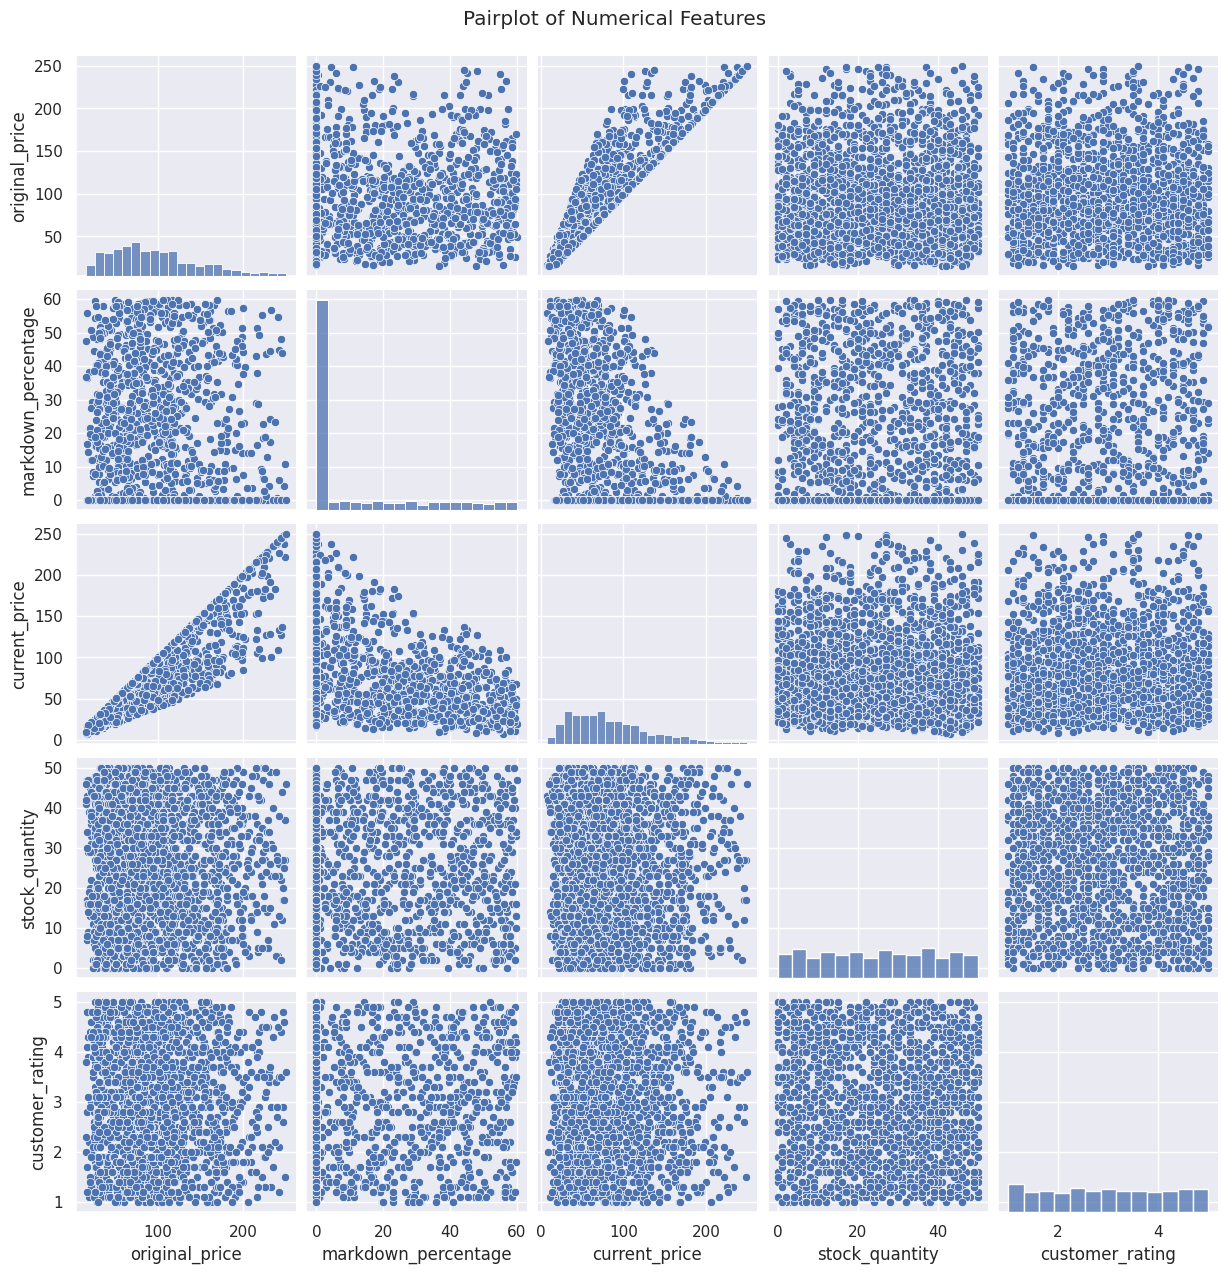

In [19]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

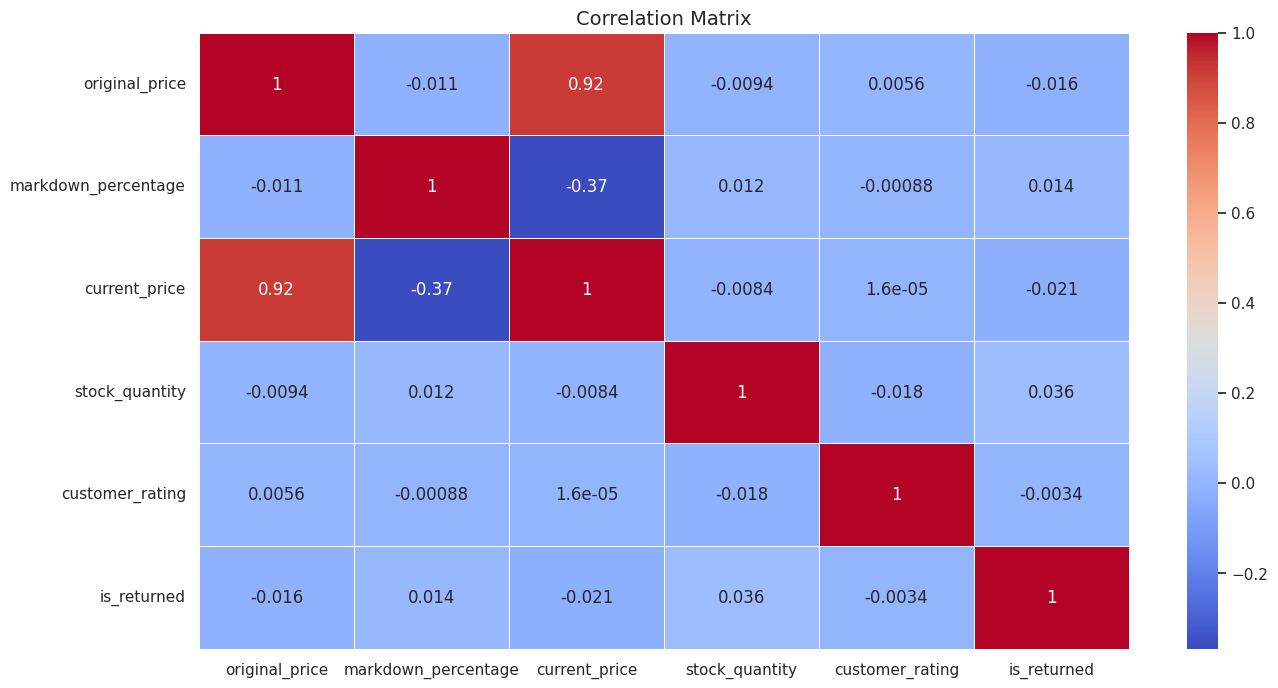

In [20]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank you